---
# I. Introduction
---

# 1.1. Library and Dataset Import

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datasets import Dataset
from google.colab import files
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split, GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, roc_curve
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [2]:
LOCAL_PATH = "/content/AnnoMI-full.csv"

def load_data():
    global _df_cache

    # 1. Memory cache
    if '_df_cache' in globals() and _df_cache is not None:
        print("---> Load data from in-memory cache")
        return _df_cache

    # 2. Local storage
    if os.path.exists(LOCAL_PATH):
        print("---> Load data from local")
        _df_cache = pd.read_csv(LOCAL_PATH)
        return _df_cache

    # 3. GitHub
    try:
        print("---> Load data from GitHub")
        github_url = "https://raw.githubusercontent.com/mthudangn/llm-therapy-fidelity/experiment/data/AnnoMI-full.csv"
        _df_cache = pd.read_csv(github_url)
        _df_cache.to_csv(LOCAL_PATH, index=False)
        return _df_cache
    except Exception as e:
        print("GitHub access expired - ", e)

    # 4. Google Drive
    drive_url = "https://drive.google.com/uc?id=1J6v0T4kFXGY_OEZXo-_0SYBLhwLy8qtl"
    try:
        print("---> Load data from Google Drive")
        _df_cache = pd.read_csv(drive_url)
        _df_cache.to_csv(LOCAL_PATH, index=False)
        return _df_cache
    except Exception:
        pass

    # 5. Manual download & upload
    print("⚠️ Please download file:\n" + drive_url + "\nand upload AnnoMI-full.csv manually")
    uploaded = files.upload()

    filename = list(uploaded.keys())[0]
    _df_cache = pd.read_csv(filename)
    _df_cache.to_csv(LOCAL_PATH, index=False)

    return _df_cache

df = load_data()

---> Load data from GitHub
GitHub access expired -  HTTP Error 404: Not Found
---> Load data from Google Drive


In [3]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (13551, 18)


,mi_quality,transcript_id,video_title,video_url,topic,utterance_id,interlocutor,timestamp,utterance_text,annotator_id,therapist_input_exists,therapist_input_subtype,reflection_exists,reflection_subtype,question_exists,question_subtype,main_therapist_behaviour,client_talk_type
0,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,0,therapist,00:00:13,Thanks for filling it out. We give this form t...,3,False,NaN,False,NaN,True,open,question,NaN
1,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,1,client,00:00:24,Sure.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
2,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,2,therapist,00:00:25,"So, let's see. It looks that you put-- You dri...",3,True,information,False,NaN,False,NaN,therapist_input,NaN
3,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,3,client,00:00:34,Mm-hmm.,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,neutral
4,high,0,"NEW VIDEO: Brief intervention: ""Barbara""",https://www.youtube.com/watch?v=PaSKcfTmFEk,reducing alcohol consumption,4,therapist,00:00:34,-and you usually have three to four drinks whe...,3,True,information,False,NaN,False,NaN,therapist_input,NaN


The original dataset contains multiple annotations per utterance. These annotations are aggregated into a single consensus label using majority voting, resulting in an utterance-level dataset used for EDA.

In [4]:
# Build utterance-level consensus dataframe
# Purpose:
# - Collapse repeated annotations for the same utterance
# - Keep one final row per (transcript_id, utterance_id)
# - Keep only columns needed for EDA & modelling

def mode_or_nan(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    s = s[s.str.lower() != "nan"]
    if len(s) == 0:
        return np.nan
    return s.mode().iloc[0]

keep_cols = [
    "transcript_id",
    "utterance_id",
    "mi_quality",
    "interlocutor",
    "utterance_text",
    "main_therapist_behaviour",
    "client_talk_type",
]

use_cols = [c for c in keep_cols if c in df.columns]

df_small = df[use_cols].copy()


# Majority vote of annotators
df_consensus = (
    df_small
    .groupby(["transcript_id", "utterance_id"], as_index=False)
    .agg({
        "mi_quality": mode_or_nan,
        "interlocutor": mode_or_nan,
        "utterance_text": mode_or_nan,
        "main_therapist_behaviour": mode_or_nan,
        "client_talk_type": mode_or_nan,
    })
    .sort_values(["transcript_id", "utterance_id"])
    .reset_index(drop=True)
)

for col in ["mi_quality", "interlocutor", "main_therapist_behaviour", "client_talk_type"]:
    if col in df_consensus.columns:
        df_consensus[col] = df_consensus[col].astype(str).str.strip().str.lower()
        df_consensus.loc[df_consensus[col] == "nan", col] = np.nan

print("Raw shape:", df.shape)
print("Consensus shape:", df_consensus.shape)
print(
    "Remaining duplicate utterances:",
    df_consensus.duplicated(subset=["transcript_id", "utterance_id"]).sum()
)

Raw shape: (13551, 18)
Consensus shape: (9699, 7)
Remaining duplicate utterances: 0


# 1.2. Data Inspection

In [5]:
print("Columns:")
print(df_consensus.columns.tolist())
print("\nData types:")
print(df_consensus.dtypes)
print("\nMissing values:")
print(df_consensus.isna().sum())

Columns:
['transcript_id', 'utterance_id', 'mi_quality', 'interlocutor', 'utterance_text', 'main_therapist_behaviour', 'client_talk_type']

Data types:
transcript_id                int64
utterance_id                 int64
mi_quality                  object
interlocutor                object
utterance_text              object
main_therapist_behaviour    object
client_talk_type            object
dtype: object

Missing values:
transcript_id                  0
utterance_id                   0
mi_quality                     0
interlocutor                   0
utterance_text                 0
main_therapist_behaviour    4817
client_talk_type            4882
dtype: int64


In [6]:
display(df_consensus.sample(min(5, len(df_consensus)), random_state=42))

,transcript_id,utterance_id,mi_quality,interlocutor,utterance_text,main_therapist_behaviour,client_talk_type
1285,22,60,high,therapist,I really applaud you for being open-minded eno...,other,NaN
3047,49,9,high,client,Mm.,NaN,neutral
1954,34,90,high,therapist,You're concerned that they're gonna kind of tr...,reflection,NaN
7463,108,52,high,therapist,"Okay, okay. Good. Um, I think you've got a goo...",question,NaN
39,0,39,high,client,"Well, I'm more ready than a six because I'm re...",NaN,change


### Value counts for important categorical columns, including subtype columns

In [7]:
for col in [
    "interlocutor",
    "main_therapist_behaviour",
    "client_talk_type",
    "mi_quality",
    "question_exists",
    "question_subtype",
    "reflection_exists",
    "reflection_subtype",
    "therapist_input_subtype"
]:
    if col in df.columns:
        print(f"\n===== {col} =====")
        print(df[col].value_counts(dropna=False))



===== interlocutor =====
interlocutor
therapist    6826
client       6725
Name: count, dtype: int64

===== main_therapist_behaviour =====
main_therapist_behaviour
NaN                6725
other              2143
question           1954
reflection         1717
therapist_input    1012
Name: count, dtype: int64

===== client_talk_type =====
client_talk_type
NaN        6826
neutral    4217
change     1668
sustain     840
Name: count, dtype: int64

===== mi_quality =====
mi_quality
high    12286
low      1265
Name: count, dtype: int64

===== question_exists =====
question_exists
NaN      6725
False    4513
True     2313
Name: count, dtype: int64

===== question_subtype =====
question_subtype
NaN       11238
open       1340
closed      973
Name: count, dtype: int64

===== reflection_exists =====
reflection_exists
NaN      6725
False    4805
True     2021
Name: count, dtype: int64

===== reflection_subtype =====
reflection_subtype
NaN        11530
simple      1070
complex      951
Name: count

# 1.3. Data Preparation: Therapist and Client Dataset Split

Each utterance is assigned a single dominant behaviour label, while additional annotation fields capture the presence of multiple behavioural elements, enabling analysis of intervention fidelity beyond simple classification.

In [8]:
therapist_df = df_consensus[df_consensus["interlocutor"] == "therapist"].copy()
client_df = df_consensus[df_consensus["interlocutor"] == "client"].copy()

print("---> Therapist rows shape:", therapist_df.shape)
print("---> Client rows shape   :", client_df.shape)

print("\n---> Therapist behaviour labels:")
print(therapist_df["main_therapist_behaviour"].value_counts(dropna=False))

print("\n---> Client talk labels:")
print(client_df["client_talk_type"].value_counts(dropna=False))

---> Therapist rows shape: (4882, 7)
---> Client rows shape   : (4817, 7)

---> Therapist behaviour labels:
main_therapist_behaviour
other              1587
question           1386
reflection         1297
therapist_input     612
Name: count, dtype: int64

---> Client talk labels:
client_talk_type
neutral    3101
change     1177
sustain     539
Name: count, dtype: int64


In [9]:
# ==========================================
# Context dataframe for Model 3 only
# ==========================================
df_context = df_consensus.copy()
df_context = df_context.sort_values(["transcript_id", "utterance_id"]).reset_index(drop=True)

df_context["utterance_text"] = (
    df_context["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df_context["prev_utterance"] = (
    df_context.groupby("transcript_id")["utterance_text"]
    .shift(1)
    .fillna("")
)

df_context["prev_interlocutor"] = (
    df_context.groupby("transcript_id")["interlocutor"]
    .shift(1)
    .fillna("")
)

df_context["context_text"] = (
    "[PREV_" + df_context["prev_interlocutor"].astype(str).str.upper() + "] "
    + df_context["prev_utterance"].astype(str)
    + " [CURR_" + df_context["interlocutor"].astype(str).str.upper() + "] "
    + df_context["utterance_text"].astype(str)
)

therapist_df_context = df_context[df_context["interlocutor"] == "therapist"].copy()
client_df_context = df_context[df_context["interlocutor"] == "client"].copy()

Behavioural complexity was quantified by counting the number of behavioural indicators (i.e., question, reflection, and therapist input) present in each therapist utterance.

The distribution indicates that the majority of utterances contain a single behavioural element (n = 3,876), consistent with the dataset’s single-label annotation scheme. A substantial proportion of utterances contain no behavioural signals (n = 2,143), corresponding to non-therapeutic or filler dialogue. Additionally, a smaller subset of utterances exhibits multiple behavioural elements (n = 747 for two behaviours and n = 60 for three behaviours), indicating that therapist responses may simultaneously fulfil multiple communicative functions.

These results demonstrate that, although each utterance is assigned a single dominant behaviour label, the underlying conversational structure is inherently multi-behavioural. This distinction is important for modelling intervention fidelity beyond simple classification.

Accordingly, intervention fidelity assessment should account for the presence of multiple behavioural signals rather than relying solely on single-label classification.

---
# II. Data Preprocessing
---

### Text Cleaning & Class Standardization

In [10]:
# # Minimal cleaning only
# # - Keep semantic content
# # - Do NOT lowercase or remove punctuation for transformer models

# print("Before text cleaning:")
# print("- Therapist data:", therapist_df.shape)
# print("- Client data:", client_df.shape)

# therapist_df["utterance_text_raw"] = therapist_df["utterance_text"].copy()
# therapist_df["utterance_text"] = (
#     therapist_df["utterance_text"]
#     .astype(str)
#     .str.replace(r"\s+", " ", regex=True)
#     .str.strip()
# )
# # Remove empty utterances after cleaning
# therapist_df = therapist_df[therapist_df["utterance_text"] != ""].copy()

# client_df["utterance_text_raw"] = client_df["utterance_text"].copy()
# client_df["utterance_text"] = (
#     client_df["utterance_text"]
#     .astype(str)
#     .str.replace(r"\s+", " ", regex=True)
#     .str.strip()
# )
# client_df = client_df[client_df["utterance_text"] != ""].copy()

# print("After text cleaning:")
# print("- Therapist data:", therapist_df.shape)
# print("- Client data:", client_df.shape)

# # Main label normalisation
# therapist_df["main_therapist_behaviour"] = (
#     therapist_df["main_therapist_behaviour"]
#     .astype(str)
#     .str.strip()
#     .str.lower()
#     .replace({"nan": "n/a", "": "n/a"})
# )

# # Useful for fidelity/session aggregation
# therapist_df["mi_quality"] = therapist_df["mi_quality"].astype(str).str.strip().str.lower()

---
# III. Exploratory Data Analysis (EDA)
---


# 3.1. Class Distribution

Therapist behaviour distribution by MI quality (%)


mi_quality,high,low
main_therapist_behaviour,,
other,32.94,28.12
question,28.03,31.97
reflection,28.51,7.03
therapist_input,10.52,32.88


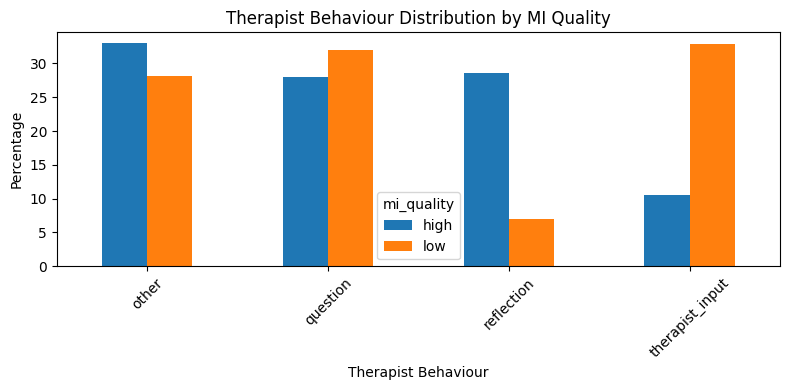

In [11]:
therapist_eda = therapist_df.dropna(subset=["main_therapist_behaviour", "mi_quality"]).copy()

therapist_counts = (
    therapist_eda
    .groupby(["mi_quality", "main_therapist_behaviour"])
    .size()
    .reset_index(name="n")
)

therapist_counts["ratio"] = therapist_counts.groupby("mi_quality")["n"].transform(lambda s: s / s.sum())

therapist_pivot = therapist_counts.pivot(
    index="main_therapist_behaviour",
    columns="mi_quality",
    values="ratio"
).fillna(0)

print("Therapist behaviour distribution by MI quality (%)")
display((therapist_pivot * 100).round(2))

(therapist_pivot * 100).plot(kind="bar", figsize=(8, 4))
plt.title("Therapist Behaviour Distribution by MI Quality")
plt.xlabel("Therapist Behaviour")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.2. Transcript MI Quality Focus

In [12]:
if "mi_quality" in therapist_df.columns:
    print(therapist_df[["transcript_id", "mi_quality"]].drop_duplicates()["mi_quality"].value_counts(dropna=False))

mi_quality
high    110
low      23
Name: count, dtype: int64


Client talk distribution by MI quality (%)


mi_quality,high,low
client_talk_type,,
change,25.13,17.18
neutral,64.05,67.78
sustain,10.82,15.04


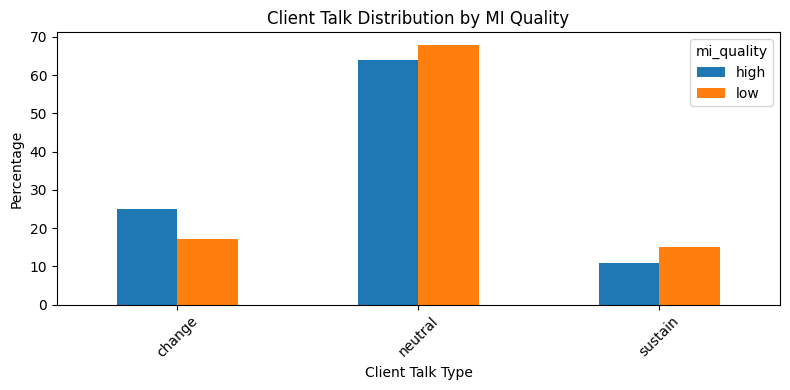

In [13]:
client_eda = client_df.dropna(subset=["client_talk_type", "mi_quality"]).copy()

client_counts = (
    client_eda
    .groupby(["mi_quality", "client_talk_type"])
    .size()
    .reset_index(name="n")
)

client_counts["ratio"] = client_counts.groupby("mi_quality")["n"].transform(lambda s: s / s.sum())

client_pivot = client_counts.pivot(
    index="client_talk_type",
    columns="mi_quality",
    values="ratio"
).fillna(0)

print("Client talk distribution by MI quality (%)")
display((client_pivot * 100).round(2))

(client_pivot * 100).plot(kind="bar", figsize=(8, 4))
plt.title("Client Talk Distribution by MI Quality")
plt.xlabel("Client Talk Type")
plt.ylabel("Percentage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
print("=== Key Pattern Check ===")

if "reflection" in therapist_pivot.index:
    print("Reflection:", (therapist_pivot.loc["reflection"] * 100).round(2).to_dict())

if "therapist_input" in therapist_pivot.index:
    print("Therapist input:", (therapist_pivot.loc["therapist_input"] * 100).round(2).to_dict())

if "question" in therapist_pivot.index:
    print("Question:", (therapist_pivot.loc["question"] * 100).round(2).to_dict())

if "change" in client_pivot.index:
    print("Change talk:", (client_pivot.loc["change"] * 100).round(2).to_dict())

if "sustain" in client_pivot.index:
    print("Sustain talk:", (client_pivot.loc["sustain"] * 100).round(2).to_dict())

=== Key Pattern Check ===
Reflection: {'high': 28.51, 'low': 7.03}
Therapist input: {'high': 10.52, 'low': 32.88}
Question: {'high': 28.03, 'low': 31.97}
Change talk: {'high': 25.13, 'low': 17.18}
Sustain talk: {'high': 10.82, 'low': 15.04}


High-quality MI sessions are characterised by a higher proportion of reflective statements and a lower proportion of directive input, whereas low-quality sessions exhibit the opposite pattern. High MI therapist tends to listen and reflect, while low MI therapist tends to tell and direct.

- Reflection ↑ in high MI because it encourages client's change talk  
- Input ↑ in low MI because it triggers client's sustain talk (resistance)

### Class Examples





In [15]:
therapist_labels = therapist_df["main_therapist_behaviour"].dropna().unique().tolist()
print("Examples of main_therapist_behaviour:")
for therapist_label in sorted(therapist_labels):
    print(f"\n===== Therapist: {therapist_label} =====")
    sample_rows = therapist_df[therapist_df["main_therapist_behaviour"] == therapist_label][["utterance_text"]].head(3)
    for i, txt in enumerate(sample_rows["utterance_text"], 1):
        print(f"{i}. {txt}")

Examples of main_therapist_behaviour:

===== Therapist: other =====
1. Great. So, let's see how well you're doing with these new meds.
2. Okay.
3. Okay. Good.

===== Therapist: question =====
1. Thanks for filling it out. We give this form to everyone once a year regardless of why they come in. It helps us provide better care. Is it okay if I take a look at what you put down?
2. Uh, what else can you tell me about your drinking.
3. Okay. So, can I share with you some information on alcohol use?

===== Therapist: reflection =====
1. Right. By the way, binge drinking is defined for women as having more than, uh, three drinks and there are about five drinks in a bottle. So, you enjoy drinking wine because it helps make things, uh, a little bit more interesting when you're feeling down but at the same time you don't like drinking when you have more than you want it to and then the depression returns after you drink.
2. Having less wine in the house will help?
3. So, it's not just wine that

In [16]:
client_labels = client_df["client_talk_type"].dropna().unique().tolist()
print("Examples of client_talk_type:")
for client_label in sorted(client_labels ):
    print(f"\n===== Client: {client_label} =====")
    sample_rows = client_df[client_df["client_talk_type"] == client_label][["utterance_text"]].head(3)
    for i, txt in enumerate(sample_rows["utterance_text"], 1):
        print(f"{i}. {txt}")

Examples of client_talk_type:

===== Client: change =====
1. Well, I don't think that I'm ready to cut down to seven drinks a week. That seems like a lot but I would consider cutting back to two drinks a night. I think that would be my goal.
2. I'd say an eight.
3. Well, I'm more ready than a six because I'm ready to cut back on my drinking and I don't wanna make my depression any worse.

===== Client: neutral =====
1. Sure.
2. Mm-hmm.
3. Usually three drinks and glasses of wine.

===== Client: sustain =====
1. Yeah, but only on the weekend.
2. So, uh, are you saying I drink too much?
3. Well, I-- If-if I was getting fallen down drunk or if I drink every night. Um, it's not like I get sloppy drunk or anything.


---
# IV. End-to-End Pipeline
---

This section implements the full methodology:

Utterance → 2 classifiers → predicted labels → aggregation → MI_quality

The pipeline has two main stages:

1. Utterance-level classification
   - Therapist utterances: utterance_text → main_therapist_behaviour
   - Client utterances: utterance_text → client_talk_type

2. Session-level MI quality prediction
   - Aggregate predicted utterance labels into transcript-level behavioural ratios
   - Use these transcript-level ratios to predict mi_quality

Note: The data is split at the transcript level, not the utterance level, so that the test transcripts remain fully held out.

In [17]:
#                     WHOLE DATASET
#                          │
#                          ▼
#               Split by transcript_id first
#                          │
#           ┌──────────────┴──────────────┐
#           │                             │
#           ▼                             ▼
#    TRAIN transcripts               TEST transcripts
#    (session_train)                 (session_test)
#           │                             │
#           │                             │
#           ▼                             ▼
#  therapist_train / client_train   therapist_test / client_test
#           │                             │
#           │                             │
#           ├───────── Utterance model ───┤
#           │                             │
#           ▼                             ▼
#    predicted utterance labels     predicted utterance labels
#           │                             │
#           ▼                             ▼
#    aggregate to session ratios    aggregate to session ratios
#           │                             │
#           ▼                             ▼
#    session_train_features         session_test_features
#           │                             │
#           └──── train session model ───▶│
#                                         ▼
#                               final MI prediction

In [18]:
# ================ LEVEL 1: RAW TEXT =================

# Therapist utterances              Client utterances
#         |                                  |
#         v                                  v
#   "How do you feel?"                "I guess I could try"
#   "That sounds hard"                "I don’t think I can"
#         |                                  |

# ================ LEVEL 2: BEHAVIOUR (CLASSIFIERS) =================

#         |                                  |
#         v                                  v
# [ Therapist Classifier ]         [ Client Classifier ]
#         |                                  |
#         v                                  v
#  main_therapist_behaviour         client_talk_type

#  question / reflection / input     change / sustain / neutral

#         \______________________________/
#                        |
#                        v

# ================ LEVEL 3: SESSION FEATURES =================

# Aggregate all predictions in ONE transcript:

# reflection_ratio
# question_ratio
# input_ratio
# change_ratio
# sustain_ratio

# (ONE ROW PER TRANSCRIPT)

#                        |
#                        v

# ================ LEVEL 4: FINAL CLASSIFIER =================

#            [ Session Model ]

#                        |
#                        v

#                 mi_quality
#               (high / low)

---
## 4.1 Transcript-Level Train-Test Split
---

The data is first split by transcript_id.

- session_train contains training transcripts
- session_test contains held-out test transcripts

This is important because MI quality is a session-level label.
Mixing utterances from the same transcript should be avoided across train and test.

In [19]:
session_labels = (
    df_consensus[["transcript_id", "mi_quality"]]
    .drop_duplicates()
    .copy()
)

session_labels["mi_quality"] = session_labels["mi_quality"].astype(str).str.strip().str.lower()
session_labels["mi_quality_binary"] = session_labels["mi_quality"].map({"low": 0, "high": 1})

session_train, session_test = train_test_split(
    session_labels,
    test_size=0.30,
    random_state=42,
    stratify=session_labels["mi_quality"]
)

train_ids = set(session_train["transcript_id"])
test_ids = set(session_test["transcript_id"])

print("Train sessions:", len(train_ids))
print("Test sessions :", len(test_ids))
print("\nTrain MI quality:")
print(session_train["mi_quality"].value_counts())
print("\nTest MI quality:")
print(session_test["mi_quality"].value_counts())

Train sessions: 93
Test sessions : 40

Train MI quality:
mi_quality
high    77
low     16
Name: count, dtype: int64

Test MI quality:
mi_quality
high    33
low      7
Name: count, dtype: int64


---
## 4.2. Therapist Utterance Classifier
---

Goal: Predict main_therapist_behaviour from therapist utterance_text.

Output:
- Out-of-fold predictions for training transcripts
- Held-out predictions for test transcripts

In [20]:
therapist_data = therapist_df[
    therapist_df["main_therapist_behaviour"].notna()
].copy()

therapist_data["utterance_text"] = (
    therapist_data["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

therapist_data = therapist_data[therapist_data["utterance_text"] != ""].copy()

therapist_train = therapist_data[
    therapist_data["transcript_id"].isin(train_ids)
].copy()

therapist_test = therapist_data[
    therapist_data["transcript_id"].isin(test_ids)
].copy()

therapist_encoder = LabelEncoder()
therapist_train["therapist_y"] = therapist_encoder.fit_transform(
    therapist_train["main_therapist_behaviour"]
)
therapist_test["therapist_y"] = therapist_encoder.transform(
    therapist_test["main_therapist_behaviour"]
)

print("Therapist train shape:", therapist_train.shape)
print("Therapist test shape :", therapist_test.shape)
print("\n---> Therapist classes:", list(therapist_encoder.classes_))

Therapist train shape: (3194, 8)
Therapist test shape : (1688, 8)

---> Therapist classes: ['other', 'question', 'reflection', 'therapist_input']


### 4.2A - Baseline Therapist Model: TF-IDF + LinearSVC



In [21]:
therapist_model_baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LinearSVC())
])

therapist_kfold = GroupKFold(n_splits=5)

therapist_train_pred_baseline = cross_val_predict(
    therapist_model_baseline,
    therapist_train["utterance_text"],
    therapist_train["therapist_y"],
    cv=therapist_kfold.split(
        therapist_train["utterance_text"],
        therapist_train["therapist_y"],
        groups=therapist_train["transcript_id"]
    ),
    method="predict"
)

therapist_model_baseline.fit(
    therapist_train["utterance_text"],
    therapist_train["therapist_y"]
)

therapist_test_pred_baseline = therapist_model_baseline.predict(
    therapist_test["utterance_text"]
)

therapist_train["pred_main_therapist_behaviour_baseline"] = therapist_encoder.inverse_transform(therapist_train_pred_baseline)
therapist_test["pred_main_therapist_behaviour_baseline"] = therapist_encoder.inverse_transform(therapist_test_pred_baseline)

therapist_train_acc_baseline = accuracy_score(therapist_train["therapist_y"], therapist_train_pred_baseline)
therapist_test_acc_baseline = accuracy_score(therapist_test["therapist_y"], therapist_test_pred_baseline)
therapist_test_f1_baseline = f1_score(therapist_test["therapist_y"], therapist_test_pred_baseline, average="macro")

print("TF-IDF + LinearSVC - Therapist train accuracy:", therapist_train_acc_baseline)
print("TF-IDF + LinearSVC - Therapist test  accuracy:", therapist_test_acc_baseline)
print("TF-IDF + LinearSVC - Therapist test  macro F1:", therapist_test_f1_baseline)

print("\n====== [Baseline: TF-IDF + LinearSV] THERAPIST classification report ======\n")
print(classification_report(
    therapist_test["therapist_y"],
    therapist_test_pred_baseline,
    target_names=therapist_encoder.classes_
))

TF-IDF + LinearSVC - Therapist train accuracy: 0.5970569818409518
TF-IDF + LinearSVC - Therapist test accuracy : 0.610781990521327
TF-IDF + LinearSVC - Therapist test macro F1: 0.5627837816865593

====== [Baseline: TF-IDF + LinearSV] THERAPIST classification report ======

                 precision    recall  f1-score   support

          other       0.81      0.80      0.81       561
       question       0.55      0.54      0.54       527
     reflection       0.52      0.55      0.54       429
therapist_input       0.37      0.36      0.36       171

       accuracy                           0.61      1688
      macro avg       0.56      0.56      0.56      1688
   weighted avg       0.61      0.61      0.61      1688



### 4.2B - Therapist Model: SBERT + LogReg

In [22]:
# ==========================================
# 4.2B Therapist Model: SBERT + LogReg
# ==========================================
# Goal: keep the same target as baseline, but replace TF-IDF with transformer embeddings.

therapist_sbert = SentenceTransformer("all-MiniLM-L6-v2")

# Text
X_therapist_train_text = therapist_train["utterance_text"].astype(str).tolist()
X_therapist_test_text  = therapist_test["utterance_text"].astype(str).tolist()

# Encode text into sentence embeddings
X_therapist_train_emb = therapist_sbert.encode(
    X_therapist_train_text,
    show_progress_bar=True
)
X_therapist_test_emb = therapist_sbert.encode(
    X_therapist_test_text,
    show_progress_bar=True
)

# Classifier (LogReg)
therapist_sbert_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)
therapist_sbert_model.fit(X_therapist_train_emb, therapist_train["therapist_y"])

# Test predictions
therapist_test_pred_sbert = therapist_sbert_model.predict(X_therapist_test_emb)
therapist_test["pred_main_therapist_behaviour_sbert"] = therapist_encoder.inverse_transform(
    therapist_test_pred_sbert
)

# Train predictions
therapist_train_pred_sbert = therapist_sbert_model.predict(X_therapist_train_emb)
therapist_train["pred_main_therapist_behaviour_sbert"] = therapist_encoder.inverse_transform(
    therapist_train_pred_sbert
)
therapist_train_acc_sbert = accuracy_score(therapist_train["therapist_y"], therapist_train_pred_sbert)
therapist_test_acc_sbert = accuracy_score(therapist_test["therapist_y"], therapist_test_pred_sbert)
therapist_test_f1_sbert = f1_score(therapist_test["therapist_y"], therapist_test_pred_sbert, average="macro")

print("SBERT + LogReg - Therapist train accuracy:", therapist_train_acc_sbert)
print("SBERT + LogReg - Therapist test  accuracy:", therapist_test_acc_sbert)
print("SBERT + LogReg - Therapist test  macro F1:", therapist_test_f1_sbert)

print("\n====== [SBERT + Logistic Regression] THERAPIST classification report ======\n")
print(classification_report(
    therapist_test["therapist_y"],
    therapist_test_pred_sbert,
    target_names=therapist_encoder.classes_
))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/100 [00:00<?, ?it/s]

Batches:   0%|          | 0/53 [00:00<?, ?it/s]

SBERT + LogReg - Therapist train accuracy: 0.7786474639949906
SBERT + LogReg - Therapist test accuracy : 0.7434834123222749
SBERT + LogReg - Therapist test macro F1: 0.7044950867046772

====== [SBERT + Logistic Regression] THERAPIST classification report ======

                 precision    recall  f1-score   support

          other       0.94      0.82      0.88       561
       question       0.80      0.76      0.78       527
     reflection       0.68      0.66      0.67       429
therapist_input       0.39      0.65      0.49       171

       accuracy                           0.74      1688
      macro avg       0.70      0.72      0.70      1688
   weighted avg       0.78      0.74      0.76      1688



### 4.2C - Therapist Model: DistilBERT + Context

In [23]:
# ==================================================
# 4.2C - Therapist Model: DistilBERT + Context
# ==================================================

therapist_data_context = therapist_df_context[
    therapist_df_context["main_therapist_behaviour"].notna()
].copy()

therapist_data_context["utterance_text"] = (
    therapist_data_context["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

therapist_data_context = therapist_data_context[
    therapist_data_context["utterance_text"] != ""
].copy()

therapist_train_ctx = therapist_data_context[
    therapist_data_context["transcript_id"].isin(train_ids)
].copy()

therapist_test_ctx = therapist_data_context[
    therapist_data_context["transcript_id"].isin(test_ids)
].copy()

therapist_train_ctx["therapist_y"] = therapist_encoder.transform(
    therapist_train_ctx["main_therapist_behaviour"]
)

therapist_test_ctx["therapist_y"] = therapist_encoder.transform(
    therapist_test_ctx["main_therapist_behaviour"]
)

model_name_ctx = "distilbert-base-uncased"
therapist_tokenizer_ctx = AutoTokenizer.from_pretrained(model_name_ctx)

def tokenize_therapist(batch):
    return therapist_tokenizer_ctx(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=64
    )

therapist_train_ds = Dataset.from_dict({
    "text": therapist_train_ctx["context_text"].tolist(),
    "label": therapist_train_ctx["therapist_y"].tolist()
}).map(tokenize_therapist, batched=True)

therapist_test_ds = Dataset.from_dict({
    "text": therapist_test_ctx["context_text"].tolist(),
    "label": therapist_test_ctx["therapist_y"].tolist()
}).map(tokenize_therapist, batched=True)

therapist_train_ds = therapist_train_ds.remove_columns(["text"])
therapist_test_ds = therapist_test_ds.remove_columns(["text"])
therapist_train_ds.set_format("torch")
therapist_test_ds.set_format("torch")

therapist_ctx_model = AutoModelForSequenceClassification.from_pretrained(
    model_name_ctx,
    num_labels=len(therapist_encoder.classes_)
)

def compute_metrics_therapist(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

therapist_ctx_args = TrainingArguments(
    output_dir="./therapist_ctx_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

therapist_ctx_trainer = Trainer(
    model=therapist_ctx_model,
    args=therapist_ctx_args,
    train_dataset=therapist_train_ds,
    eval_dataset=therapist_test_ds,
    compute_metrics=compute_metrics_therapist
)

therapist_ctx_trainer.train()

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3194 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=800, training_loss=0.6567843937873841, metrics={'train_runtime': 113.5471, 'train_samples_per_second': 112.517, 'train_steps_per_second': 7.046, 'total_flos': 211557981057024.0, 'train_loss': 0.6567843937873841, 'epoch': 4.0})

In [24]:
therapist_test_output_ctx = therapist_ctx_trainer.predict(therapist_test_ds)
therapist_test_pred_ctx = np.argmax(therapist_test_output_ctx.predictions, axis=1)

therapist_train_output_ctx = therapist_ctx_trainer.predict(therapist_train_ds)
therapist_train_pred_ctx = np.argmax(therapist_train_output_ctx.predictions, axis=1)

therapist_test_ctx["pred_main_therapist_behaviour_ctx"] = therapist_encoder.inverse_transform(
    therapist_test_pred_ctx
)
therapist_train_ctx["pred_main_therapist_behaviour_ctx"] = therapist_encoder.inverse_transform(
    therapist_train_pred_ctx
)

therapist_train_acc_ctx = accuracy_score(therapist_train_ctx["therapist_y"], therapist_train_pred_ctx)
therapist_test_acc_ctx = accuracy_score(therapist_test_ctx["therapist_y"], therapist_test_pred_ctx)
therapist_test_f1_ctx = f1_score(therapist_test_ctx["therapist_y"], therapist_test_pred_ctx, average="macro")

print("DistilBERT + CTX - Therapist train accuracy:", therapist_train_acc_ctx)
print("DistilBERT + CTX - Therapist test  accuracy:", therapist_test_acc_ctx)
print("DistilBERT + CTX - Therapist test  macro F1:", therapist_test_f1_ctx)

print("\n====== [DistilBERT + Context] THERAPIST classification report ======\n")
print(classification_report(
    therapist_test_ctx["therapist_y"],
    therapist_test_pred_ctx,
    target_names=therapist_encoder.classes_
))

DistilBERT + CTX - Therapist train accuracy: 0.8503443957420163
DistilBERT + CTX - Therapist test accuracy : 0.7369668246445498
DistilBERT + CTX - Therapist test macro F1: 0.6998652526258025

====== [DistilBERT + Context] THERAPIST classification report ======

                 precision    recall  f1-score   support

          other       0.86      0.77      0.81       561
       question       0.80      0.76      0.78       527
     reflection       0.62      0.75      0.68       429
therapist_input       0.55      0.51      0.53       171

       accuracy                           0.74      1688
      macro avg       0.71      0.70      0.70      1688
   weighted avg       0.75      0.74      0.74      1688



### 4.2D - Therapist Model: RoBERTa

In [25]:
# ==========================================
# 4.2D - Therapist Model: RoBERTa (no context)
# ==========================================

therapist_data_roberta = therapist_df[
    therapist_df["main_therapist_behaviour"].notna()
].copy()

therapist_data_roberta["utterance_text"] = (
    therapist_data_roberta["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

therapist_data_roberta = therapist_data_roberta[
    therapist_data_roberta["utterance_text"] != ""
].copy()

therapist_train_roberta = therapist_data_roberta[
    therapist_data_roberta["transcript_id"].isin(train_ids)
].copy()

therapist_test_roberta = therapist_data_roberta[
    therapist_data_roberta["transcript_id"].isin(test_ids)
].copy()

therapist_train_roberta["therapist_y"] = therapist_encoder.transform(
    therapist_train_roberta["main_therapist_behaviour"]
)

therapist_test_roberta["therapist_y"] = therapist_encoder.transform(
    therapist_test_roberta["main_therapist_behaviour"]
)

therapist_roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_therapist_roberta(batch):
    return therapist_roberta_tokenizer(
        batch["utterance_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

therapist_train_ds_roberta = Dataset.from_pandas(
    therapist_train_roberta[["utterance_text", "therapist_y"]]
).map(tokenize_therapist_roberta, batched=True)

therapist_test_ds_roberta = Dataset.from_pandas(
    therapist_test_roberta[["utterance_text", "therapist_y"]]
).map(tokenize_therapist_roberta, batched=True)

therapist_train_ds_roberta = therapist_train_ds_roberta.remove_columns(
    [col for col in therapist_train_ds_roberta.column_names if col not in ["input_ids", "attention_mask", "therapist_y"]]
)
therapist_test_ds_roberta = therapist_test_ds_roberta.remove_columns(
    [col for col in therapist_test_ds_roberta.column_names if col not in ["input_ids", "attention_mask", "therapist_y"]]
)

therapist_train_ds_roberta = therapist_train_ds_roberta.rename_column("therapist_y", "label")
therapist_test_ds_roberta = therapist_test_ds_roberta.rename_column("therapist_y", "label")

therapist_train_ds_roberta.set_format("torch")
therapist_test_ds_roberta.set_format("torch")

therapist_roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(therapist_encoder.classes_)
)

def compute_metrics_therapist_roberta(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

therapist_roberta_args = TrainingArguments(
    output_dir="./therapist_roberta_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    save_total_limit=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

therapist_roberta_trainer = Trainer(
    model=therapist_roberta_model,
    args=therapist_roberta_args,
    train_dataset=therapist_train_ds_roberta,
    eval_dataset=therapist_test_ds_roberta,
    compute_metrics=compute_metrics_therapist_roberta
)

therapist_roberta_trainer.train()

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=800, training_loss=0.4548324406147003, metrics={'train_runtime': 406.5592, 'train_samples_per_second': 31.425, 'train_steps_per_second': 1.968, 'total_flos': 840391801626624.0, 'train_loss': 0.4548324406147003, 'epoch': 4.0})

In [26]:
therapist_test_output_roberta = therapist_roberta_trainer.predict(therapist_test_ds_roberta)
therapist_test_pred_roberta = np.argmax(therapist_test_output_roberta.predictions, axis=1)

therapist_train_output_roberta = therapist_roberta_trainer.predict(therapist_train_ds_roberta)
therapist_train_pred_roberta = np.argmax(therapist_train_output_roberta.predictions, axis=1)

therapist_test_roberta["pred_main_therapist_behaviour_roberta"] = therapist_encoder.inverse_transform(
    therapist_test_pred_roberta
)

therapist_train_roberta["pred_main_therapist_behaviour_roberta"] = therapist_encoder.inverse_transform(
    therapist_train_pred_roberta
)

therapist_train_acc_roberta = accuracy_score(
    therapist_train_roberta["therapist_y"], therapist_train_pred_roberta
)
therapist_test_acc_roberta = accuracy_score(
    therapist_test_roberta["therapist_y"], therapist_test_pred_roberta
)
therapist_test_f1_roberta = f1_score(
    therapist_test_roberta["therapist_y"], therapist_test_pred_roberta, average="macro"
)

print("[RoBERTa] Therapist train accuracy:", therapist_train_acc_roberta)
print("[RoBERTa] Therapist test  accuracy:", therapist_test_acc_roberta)
print("[RoBERTa] Therapist test  macro F1:", therapist_test_f1_roberta)

print("\n====== [RoBERTa] THERAPIST classification report ======\n")
print(classification_report(
    therapist_test_roberta["therapist_y"],
    therapist_test_pred_roberta,
    target_names=therapist_encoder.classes_
))

RoBERTa - Therapist train accuracy: 0.8368816530995616
RoBERTa - Therapist test accuracy : 0.816350710900474
RoBERTa - Therapist test macro F1: 0.7772704154684198

====== [RoBERTa] THERAPIST classification report ======

                 precision    recall  f1-score   support

          other       0.97      0.82      0.89       561
       question       0.84      0.90      0.87       527
     reflection       0.75      0.77      0.76       429
therapist_input       0.54      0.65      0.59       171

       accuracy                           0.82      1688
      macro avg       0.77      0.79      0.78      1688
   weighted avg       0.83      0.82      0.82      1688



---
## 4.3. Client Utterance Classifier
---

Goal:
Predict client_talk_type from client utterance_text.

Output:
- Out-of-fold predictions for training transcripts
- Held-out predictions for test transcripts

Examples:
- TF-IDF: "That makes sense"

❌ no connection to previous
❌ just word counts

- SBERT: "That makes sense"

✅ understands meaning
❌ still isolated

- DistilBERT + context: [PREV] ... + [CURR] ...

✅ understands meaning
✅ understands relationship

In [27]:
client_data = client_df[
    client_df["client_talk_type"].notna()
].copy()

client_data["utterance_text"] = (
    client_data["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

client_data = client_data[client_data["utterance_text"] != ""].copy()

client_train = client_data[
    client_data["transcript_id"].isin(train_ids)
].copy()

client_test = client_data[
    client_data["transcript_id"].isin(test_ids)
].copy()

client_encoder = LabelEncoder()
client_train["client_y"] = client_encoder.fit_transform(
    client_train["client_talk_type"]
)
client_test["client_y"] = client_encoder.transform(
    client_test["client_talk_type"]
)

print("Client train shape:", client_train.shape)
print("Client test shape: ", client_test.shape)
print("\n---> Client classes:", list(client_encoder.classes_))

Client train shape: (3153, 8)
Client test shape:  (1664, 8)

---> Client classes: ['change', 'neutral', 'sustain']


### 4.3A - Baseline Client Model: TF-IDF + LinearSVC

In [28]:
client_model_baseline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words="english")),
    ("clf", LinearSVC())
])

client_kfold = GroupKFold(n_splits=5)

client_train_pred_baseline = cross_val_predict(
    client_model_baseline,
    client_train["utterance_text"],
    client_train["client_y"],
    cv=client_kfold.split(
        client_train["utterance_text"],
        client_train["client_y"],
        groups=client_train["transcript_id"]
    ),
    method="predict"
)

client_model_baseline.fit(
    client_train["utterance_text"],
    client_train["client_y"]
)

client_test_pred_baseline = client_model_baseline.predict(
    client_test["utterance_text"]
)

client_train["pred_client_talk_type_baseline"] = client_encoder.inverse_transform(client_train_pred_baseline)
client_test["pred_client_talk_type_baseline"] = client_encoder.inverse_transform(client_test_pred_baseline)

client_train_acc_baseline = accuracy_score(client_train["client_y"], client_train_pred_baseline)
client_test_acc_baseline = accuracy_score(client_test["client_y"], client_test_pred_baseline)
client_test_f1_baseline = f1_score(client_test["client_y"], client_test_pred_baseline, average="macro")

print("[TF-IDF + LinearSVC] Client train accuracy:", client_train_acc_baseline)
print("[TF-IDF + LinearSVC] Client test  accuracy:", client_test_acc_baseline)
print("[TF-IDF + LinearSVC] Client test  macro F1:", client_test_f1_baseline)

print("\n====== [Baseline: TF-IDF + LinearSVC] CLIENT classification report ======\n")
print(classification_report(
    client_test["client_y"],
    client_test_pred_baseline,
    target_names=client_encoder.classes_
))

TF-IDF + LinearSVC - Client train accuracy: 0.6384395813510942
TF-IDF + LinearSVC - Client test accuracy : 0.6105769230769231
TF-IDF + LinearSVC - Client test macro F1: 0.4289692309915932

====== [Baseline: TF-IDF + LinearSVC] CLIENT classification report ======

              precision    recall  f1-score   support

      change       0.44      0.25      0.32       446
     neutral       0.66      0.86      0.75      1010
     sustain       0.38      0.15      0.22       208

    accuracy                           0.61      1664
   macro avg       0.49      0.42      0.43      1664
weighted avg       0.56      0.61      0.57      1664



### 4.3B - Client Model: SBERT + LogReg

In [29]:
# ==========================================
# 4.3B - Client Model: SBERT + LogReg
# ==========================================
# Goal: transformer embeddings

client_sbert = SentenceTransformer("all-MiniLM-L6-v2")

# Text
X_client_train_text = client_train["utterance_text"].astype(str).tolist()
X_client_test_text  = client_test["utterance_text"].astype(str).tolist()

# Encode text into sentence embeddings
X_client_train_emb = client_sbert.encode(
    X_client_train_text,
    show_progress_bar=True
)
X_client_test_emb = client_sbert.encode(
    X_client_test_text,
    show_progress_bar=True
)

# Classifier
client_sbert_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)
client_sbert_model.fit(X_client_train_emb, client_train["client_y"])

# Test predictions
client_test_pred_sbert = client_sbert_model.predict(X_client_test_emb)
client_test["pred_client_talk_type_sbert"] = client_encoder.inverse_transform(
    client_test_pred_sbert
)

# Train predictions
client_train_pred_sbert = client_sbert_model.predict(X_client_train_emb)
client_train["pred_client_talk_type_sbert"] = client_encoder.inverse_transform(
    client_train_pred_sbert
)

client_train_acc_sbert = accuracy_score(client_train["client_y"], client_train_pred_sbert)
client_test_acc_sbert = accuracy_score(client_test["client_y"], client_test_pred_sbert)
client_test_f1_sbert = f1_score(client_test["client_y"], client_test_pred_sbert, average="macro")

print("[SBERT + LogReg] Client train accuracy:", client_train_acc_sbert)
print("[SBERT + LogReg] Client test  accuracy:", client_test_acc_sbert)
print("[SBERT + LogReg] Client test  macro F1:", client_test_f1_sbert)

print("\n====== [SBERT + Logistic Regression] CLIENT classification report ======\n")
print(classification_report(
    client_test["client_y"],
    client_test_pred_sbert,
    target_names=client_encoder.classes_
))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/99 [00:00<?, ?it/s]

Batches:   0%|          | 0/52 [00:00<?, ?it/s]

SBERT + LogReg - Client train accuracy: 0.6784015223596574
SBERT + LogReg - Client test accuracy : 0.578125
SBERT + LogReg - Client test macro F1: 0.5010618816897257

====== [SBERT + Logistic Regression] CLIENT classification report ======

              precision    recall  f1-score   support

      change       0.47      0.43      0.45       446
     neutral       0.78      0.66      0.72      1010
     sustain       0.25      0.50      0.34       208

    accuracy                           0.58      1664
   macro avg       0.50      0.53      0.50      1664
weighted avg       0.63      0.58      0.60      1664



### 4.3C - Client Model: DistilBERT + Context

utterance-level independent modeling --> context-aware utterance modeling

Unlike TF-IDF, transformer uses self-attention, meaning that each word can “look at” other words i.e. current utterance connects with previous utterance. The model does not explicitly know “this is context” even it is context-based model. It just sees a longer sentence and learns relationships.

Example:
- [PREV] I feel stressed → [CURR] That sounds hard → reflection
- [PREV] I don’t know → [CURR] What do you think? → question

For therapist model:

- input = prev + current therapist utterance
- target = main_therapist_behaviour of the current therapist utterance

For client model:

- input = prev + current client utterance
- target = client_talk_type of the current client utterance

In [30]:
import torch
print(torch.cuda.is_available()) # Check GPU = True

True


In [31]:
# ==========================================
# 4.3C - Client Model: DistilBERT + Context
# ==========================================

client_data_context = client_df_context[
    client_df_context["client_talk_type"].notna()
].copy()

client_data_context["utterance_text"] = (
    client_data_context["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

client_data_context = client_data_context[
    client_data_context["utterance_text"] != ""
].copy()

client_train_ctx = client_data_context[
    client_data_context["transcript_id"].isin(train_ids)
].copy()

client_test_ctx = client_data_context[
    client_data_context["transcript_id"].isin(test_ids)
].copy()

client_train_ctx["client_y"] = client_encoder.transform(
    client_train_ctx["client_talk_type"]
)

client_test_ctx["client_y"] = client_encoder.transform(
    client_test_ctx["client_talk_type"]
)

model_name_client_ctx = "distilbert-base-uncased"
client_tokenizer_ctx = AutoTokenizer.from_pretrained(model_name_client_ctx)

def tokenize_client(batch):
    return client_tokenizer_ctx(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

client_train_ds = Dataset.from_dict({
    "text": client_train_ctx["context_text"].tolist(),
    "label": client_train_ctx["client_y"].tolist()
}).map(tokenize_client, batched=True)

client_test_ds = Dataset.from_dict({
    "text": client_test_ctx["context_text"].tolist(),
    "label": client_test_ctx["client_y"].tolist()
}).map(tokenize_client, batched=True)

client_train_ds = client_train_ds.remove_columns(["text"])
client_test_ds = client_test_ds.remove_columns(["text"])
client_train_ds.set_format("torch")
client_test_ds.set_format("torch")

client_ctx_model = AutoModelForSequenceClassification.from_pretrained(
    model_name_client_ctx,
    num_labels=len(client_encoder.classes_)
)

def compute_metrics_client(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

client_ctx_args = TrainingArguments(
    output_dir="./client_ctx_model",
    eval_strategy="epoch",
    save_strategy="epoch",              # must save each epoch
    load_best_model_at_end=True,        # load best checkpoint
    metric_for_best_model="eval_loss",  # choose best by validation loss
    greater_is_better=False,
    save_total_limit=1,                 # keep ONLY best model
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

client_ctx_trainer = Trainer(
    model=client_ctx_model,
    args=client_ctx_args,
    train_dataset=client_train_ds,
    eval_dataset=client_test_ds,
    compute_metrics=compute_metrics_client
)

client_ctx_trainer.train()

Map:   0%|          | 0/3153 [00:00<?, ? examples/s]

Map:   0%|          | 0/1664 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.744592,0.802562,0.658053
2,0.671424,0.805385,0.664062
3,0.539705,0.838971,0.647236
4,0.451551,0.863411,0.647837


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=792, training_loss=0.6051256921556261, metrics={'train_runtime': 234.4683, 'train_samples_per_second': 53.79, 'train_steps_per_second': 3.378, 'total_flos': 417677156508672.0, 'train_loss': 0.6051256921556261, 'epoch': 4.0})

In [32]:
client_test_output_ctx = client_ctx_trainer.predict(client_test_ds)
client_test_pred_ctx = np.argmax(client_test_output_ctx.predictions, axis=1)

client_train_output_ctx = client_ctx_trainer.predict(client_train_ds)
client_train_pred_ctx = np.argmax(client_train_output_ctx.predictions, axis=1)

client_test_ctx["pred_client_talk_type_ctx"] = client_encoder.inverse_transform(
    client_test_pred_ctx
)
client_train_ctx["pred_client_talk_type_ctx"] = client_encoder.inverse_transform(
    client_train_pred_ctx
)

client_train_acc_ctx = accuracy_score(client_train_ctx["client_y"], client_train_pred_ctx)
client_test_acc_ctx = accuracy_score(client_test_ctx["client_y"], client_test_pred_ctx)
client_test_f1_ctx = f1_score(client_test_ctx["client_y"], client_test_pred_ctx, average="macro")

print("[DistilBERT + CTX] Client train accuracy:", client_train_acc_ctx)
print("[DistilBERT + CTX] Client test  accuracy:", client_test_acc_ctx)
print("[DistilBERT + CTX] Client test  macro F1:", client_test_f1_ctx)

print("\n====== [DistilBERT + Context] CLIENT classification report ======\n")
print(classification_report(
    client_test_ctx["client_y"],
    client_test_pred_ctx,
    target_names=client_encoder.classes_
))

DistilBERT + CTX - Client train accuracy: 0.7161433555344117
DistilBERT + CTX - Client test accuracy : 0.6574519230769231
DistilBERT + CTX - Client test macro F1: 0.4295377272309897

====== [DistilBERT + Context] CLIENT classification report ======

              precision    recall  f1-score   support

      change       0.51      0.49      0.50       446
     neutral       0.71      0.87      0.78      1010
     sustain       1.00      0.00      0.01       208

    accuracy                           0.66      1664
   macro avg       0.74      0.45      0.43      1664
weighted avg       0.69      0.66      0.61      1664



### 4.3D - Client Model: RoBERTa

In [33]:
# ==========================================
# 4.3D - Client Model: RoBERTa (no context)
# ==========================================

client_data_roberta = client_df[
    client_df["client_talk_type"].notna()
].copy()

client_data_roberta["utterance_text"] = (
    client_data_roberta["utterance_text"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

client_data_roberta = client_data_roberta[
    client_data_roberta["utterance_text"] != ""
].copy()

client_train_roberta = client_data_roberta[
    client_data_roberta["transcript_id"].isin(train_ids)
].copy()

client_test_roberta = client_data_roberta[
    client_data_roberta["transcript_id"].isin(test_ids)
].copy()

client_train_roberta["client_y"] = client_encoder.transform(
    client_train_roberta["client_talk_type"]
)

client_test_roberta["client_y"] = client_encoder.transform(
    client_test_roberta["client_talk_type"]
)

client_roberta_tokenizer = AutoTokenizer.from_pretrained("roberta-base")

def tokenize_client_roberta(batch):
    return client_roberta_tokenizer(
        batch["utterance_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

client_train_ds_roberta = Dataset.from_pandas(
    client_train_roberta[["utterance_text", "client_y"]]
).map(tokenize_client_roberta, batched=True)

client_test_ds_roberta = Dataset.from_pandas(
    client_test_roberta[["utterance_text", "client_y"]]
).map(tokenize_client_roberta, batched=True)

client_train_ds_roberta = client_train_ds_roberta.remove_columns(
    [col for col in client_train_ds_roberta.column_names if col not in ["input_ids", "attention_mask", "client_y"]]
)
client_test_ds_roberta = client_test_ds_roberta.remove_columns(
    [col for col in client_test_ds_roberta.column_names if col not in ["input_ids", "attention_mask", "client_y"]]
)

client_train_ds_roberta = client_train_ds_roberta.rename_column("client_y", "label")
client_test_ds_roberta = client_test_ds_roberta.rename_column("client_y", "label")

client_train_ds_roberta.set_format("torch")
client_test_ds_roberta.set_format("torch")

client_roberta_model = AutoModelForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=len(client_encoder.classes_)
)

def compute_metrics_client_roberta(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": accuracy_score(labels, preds)}

client_roberta_args = TrainingArguments(
    output_dir="./client_roberta_model",
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    logging_steps=50,
    report_to="none"
)

client_roberta_trainer = Trainer(
    model=client_roberta_model,
    args=client_roberta_args,
    train_dataset=client_train_ds_roberta,
    eval_dataset=client_test_ds_roberta,
    compute_metrics=compute_metrics_client_roberta
)

client_roberta_trainer.train()

Map:   0%|          | 0/3153 [00:00<?, ? examples/s]

Map:   0%|          | 0/1664 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,0.780003,0.817348,0.659856
2,0.689243,0.779752,0.682091
3,0.530044,0.824449,0.689904
4,0.466841,0.908531,0.682692


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=792, training_loss=0.6188362294977362, metrics={'train_runtime': 427.052, 'train_samples_per_second': 29.533, 'train_steps_per_second': 1.855, 'total_flos': 829596606096384.0, 'train_loss': 0.6188362294977362, 'epoch': 4.0})

In [34]:
client_test_output_roberta = client_roberta_trainer.predict(client_test_ds_roberta)
client_test_pred_roberta = np.argmax(client_test_output_roberta.predictions, axis=1)

client_train_output_roberta = client_roberta_trainer.predict(client_train_ds_roberta)
client_train_pred_roberta = np.argmax(client_train_output_roberta.predictions, axis=1)

client_test_roberta["pred_client_talk_type_roberta"] = client_encoder.inverse_transform(
    client_test_pred_roberta
)

client_train_roberta["pred_client_talk_type_roberta"] = client_encoder.inverse_transform(
    client_train_pred_roberta
)

client_train_acc_roberta = accuracy_score(
    client_train_roberta["client_y"], client_train_pred_roberta
)
client_test_acc_roberta = accuracy_score(
    client_test_roberta["client_y"], client_test_pred_roberta
)
client_test_f1_roberta = f1_score(
    client_test_roberta["client_y"], client_test_pred_roberta, average="macro"
)

print("[RoBERTa] Client train accuracy:", client_train_acc_roberta)
print("[RoBERTa] Client test  accuracy:", client_test_acc_roberta)
print("[RoBERTa] Client test  macro F1:", client_test_f1_roberta)

print("\n======== [RoBERTa] CLIENT classification report ========\n")
print(classification_report(
    client_test_roberta["client_y"],
    client_test_pred_roberta,
    target_names=client_encoder.classes_
))

[RoBERTa] Client train accuracy: 0.7998731366952109
[RoBERTa] Client test accuracy : 0.6832932692307693
[RoBERTa] Client test macro F1: 0.5372501906888992

======== [RoBERTa] CLIENT classification report ========

              precision    recall  f1-score   support

      change       0.66      0.35      0.46       446
     neutral       0.70      0.91      0.79      1010
     sustain       0.53      0.27      0.36       208

    accuracy                           0.68      1664
   macro avg       0.63      0.51      0.54      1664
weighted avg       0.67      0.68      0.65      1664



---
## 4.4. Predicted Label Aggregation
---

At this stage, gold utterance labels are not used. Instead, aggregate therapist and client predicted labels:
- pred_main_therapist_behaviour
- pred_client_talk_type

into transcript-level ratios such as:
- reflection_ratio
- question_ratio
- input_ratio
- change_ratio
- sustain_ratio

These aggregated features form the session-level representation.

In [35]:
def build_session_features(therapist_pred_df, client_pred_df, session_df):
    therapist_counts = (
        therapist_pred_df
        .groupby(["transcript_id", "pred_main_therapist_behaviour"])
        .size()
        .unstack(fill_value=0)
    )

    client_counts = (
        client_pred_df
        .groupby(["transcript_id", "pred_client_talk_type"])
        .size()
        .unstack(fill_value=0)
    )

    for col in ["reflection", "question", "therapist_input", "other"]:
        if col not in therapist_counts.columns:
            therapist_counts[col] = 0

    for col in ["change", "sustain", "neutral"]:
        if col not in client_counts.columns:
            client_counts[col] = 0

    therapist_counts["therapist_total"] = therapist_counts[["reflection", "question", "therapist_input", "other"]].sum(axis=1)
    client_counts["client_total"] = client_counts[["change", "sustain", "neutral"]].sum(axis=1)

    therapist_counts["reflection_ratio"] = therapist_counts["reflection"] / therapist_counts["therapist_total"]
    therapist_counts["question_ratio"] = therapist_counts["question"] / therapist_counts["therapist_total"]
    therapist_counts["input_ratio"] = therapist_counts["therapist_input"] / therapist_counts["therapist_total"]

    client_counts["change_ratio"] = client_counts["change"] / client_counts["client_total"]
    client_counts["sustain_ratio"] = client_counts["sustain"] / client_counts["client_total"]

    session_features = (
        session_df
        .merge(
            therapist_counts[["reflection_ratio", "question_ratio", "input_ratio"]],
            left_on="transcript_id",
            right_index=True,
            how="left"
        )
        .merge(
            client_counts[["change_ratio", "sustain_ratio"]],
            left_on="transcript_id",
            right_index=True,
            how="left"
        )
        .fillna(0)
    )

    return session_features

### 4.4A - Baseline Session Aggregation: TF-IDF + LinearSVC

In [36]:
session_train_features_baseline = build_session_features(
    therapist_train[["transcript_id", "pred_main_therapist_behaviour_baseline"]].rename(
        columns={"pred_main_therapist_behaviour_baseline": "pred_main_therapist_behaviour"}
    ),
    client_train[["transcript_id", "pred_client_talk_type_baseline"]].rename(
        columns={"pred_client_talk_type_baseline": "pred_client_talk_type"}
    ),
    session_train
)

session_test_features_baseline = build_session_features(
    therapist_test[["transcript_id", "pred_main_therapist_behaviour_baseline"]].rename(
        columns={"pred_main_therapist_behaviour_baseline": "pred_main_therapist_behaviour"}
    ),
    client_test[["transcript_id", "pred_client_talk_type_baseline"]].rename(
        columns={"pred_client_talk_type_baseline": "pred_client_talk_type"}
    ),
    session_test
)

print("[Baseline: TF-IDF + LinearSVC] Session train features:", session_train_features_baseline.shape)
display(session_train_features_baseline.head())
print("\n[Baseline: TF-IDF + LinearSVC] Session test features:", session_test_features_baseline.shape)
display(session_test_features_baseline.head())

[Baseline: TF-IDF + LinearSVC] Session train features: (93, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
6119,92,low,0,0.142857,0.285714,0.285714,0.333333,0.000000
3316,53,low,0,0.240741,0.222222,0.314815,0.203704,0.037037
8971,126,low,0,0.194444,0.277778,0.416667,0.285714,0.000000
7615,111,high,1,0.300000,0.500000,0.100000,0.068966,0.068966
5467,84,high,1,0.288136,0.372881,0.008475,0.145299,0.017094



[Baseline: TF-IDF + LinearSVC] Session test features: (40, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
1981,35,high,1,0.555556,0.277778,0.000000,0.294118,0.058824
7674,112,high,1,0.272727,0.181818,0.090909,0.125000,0.062500
798,18,high,1,0.344828,0.206897,0.068966,0.192982,0.052632
6455,98,high,1,0.223350,0.324873,0.111675,0.167513,0.065990
4744,70,high,1,0.000000,0.333333,0.333333,0.166667,0.000000


### 4.4B - Session Aggregation: SBERT + Logistic Regression

In [37]:
session_train_features_sbert = build_session_features(
    therapist_train[["transcript_id", "pred_main_therapist_behaviour_sbert"]].rename(
        columns={"pred_main_therapist_behaviour_sbert": "pred_main_therapist_behaviour"}
    ),
    client_train[["transcript_id", "pred_client_talk_type_sbert"]].rename(
        columns={"pred_client_talk_type_sbert": "pred_client_talk_type"}
    ),
    session_train
)

session_test_features_sbert = build_session_features(
    therapist_test[["transcript_id", "pred_main_therapist_behaviour_sbert"]].rename(
        columns={"pred_main_therapist_behaviour_sbert": "pred_main_therapist_behaviour"}
    ),
    client_test[["transcript_id", "pred_client_talk_type_sbert"]].rename(
        columns={"pred_client_talk_type_sbert": "pred_client_talk_type"}
    ),
    session_test
)

print("[SBERT + Logistic Regression] Session train features:", session_train_features_sbert.shape)
display(session_train_features_sbert.head())
print("\n[SBERT + Logistic Regression] Session test features:", session_test_features_sbert.shape)
display(session_test_features_sbert.head())

[SBERT + Logistic Regression] Session train features: (93, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
6119,92,low,0,0.000000,0.142857,0.714286,0.000000,0.333333
3316,53,low,0,0.092593,0.444444,0.333333,0.277778,0.166667
8971,126,low,0,0.000000,0.277778,0.666667,0.142857,0.142857
7615,111,high,1,0.300000,0.366667,0.300000,0.137931,0.448276
5467,84,high,1,0.423729,0.415254,0.042373,0.145299,0.205128



[SBERT + Logistic Regression] Session test features: (40, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
1981,35,high,1,0.611111,0.222222,0.055556,0.411765,0.176471
7674,112,high,1,0.242424,0.212121,0.121212,0.343750,0.375000
798,18,high,1,0.241379,0.413793,0.034483,0.140351,0.228070
6455,98,high,1,0.228426,0.329949,0.121827,0.197970,0.299492
4744,70,high,1,0.000000,0.333333,0.500000,0.333333,0.333333


### 4.4C - Session Aggregation: DistilBERT + Context

In [38]:
session_train_features_ctx = build_session_features(
    therapist_train_ctx[["transcript_id", "pred_main_therapist_behaviour_ctx"]].rename(
        columns={"pred_main_therapist_behaviour_ctx": "pred_main_therapist_behaviour"}
    ),
    client_train_ctx[["transcript_id", "pred_client_talk_type_ctx"]].rename(
        columns={"pred_client_talk_type_ctx": "pred_client_talk_type"}
    ),
    session_train
)

session_test_features_ctx = build_session_features(
    therapist_test_ctx[["transcript_id", "pred_main_therapist_behaviour_ctx"]].rename(
        columns={"pred_main_therapist_behaviour_ctx": "pred_main_therapist_behaviour"}
    ),
    client_test_ctx[["transcript_id", "pred_client_talk_type_ctx"]].rename(
        columns={"pred_client_talk_type_ctx": "pred_client_talk_type"}
    ),
    session_test
)

print("[DistilBERT + Context] Session train features:", session_train_features_ctx.shape)
display(session_train_features_ctx.head())

print("\n[DistilBERT + Context] Session test features:", session_test_features_ctx.shape)
display(session_test_features_ctx.head())

[DistilBERT + Context] Session train features: (93, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
6119,92,low,0,0.000000,0.142857,0.714286,0.500000,0.0
3316,53,low,0,0.166667,0.500000,0.203704,0.166667,0.0
8971,126,low,0,0.027778,0.361111,0.527778,0.214286,0.0
7615,111,high,1,0.300000,0.400000,0.266667,0.379310,0.0
5467,84,high,1,0.483051,0.355932,0.042373,0.128205,0.0



[DistilBERT + Context] Session test features: (40, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
1981,35,high,1,0.333333,0.500000,0.000000,0.470588,0.000000
7674,112,high,1,0.424242,0.212121,0.030303,0.468750,0.000000
798,18,high,1,0.275862,0.396552,0.034483,0.122807,0.000000
6455,98,high,1,0.314721,0.248731,0.045685,0.182741,0.005076
4744,70,high,1,0.000000,0.500000,0.333333,0.000000,0.000000


### 4.4D - Session Aggregation: RoBERTa

In [66]:
session_train_features_roberta = build_session_features(
    therapist_train_roberta[["transcript_id", "pred_main_therapist_behaviour_roberta"]].rename(
        columns={"pred_main_therapist_behaviour_roberta": "pred_main_therapist_behaviour"}
    ),
    client_train_roberta[["transcript_id", "pred_client_talk_type_roberta"]].rename(
        columns={"pred_client_talk_type_roberta": "pred_client_talk_type"}
    ),
    session_train
)

session_test_features_roberta = build_session_features(
    therapist_test_roberta[["transcript_id", "pred_main_therapist_behaviour_roberta"]].rename(
        columns={"pred_main_therapist_behaviour_roberta": "pred_main_therapist_behaviour"}
    ),
    client_test_roberta[["transcript_id", "pred_client_talk_type_roberta"]].rename(
        columns={"pred_client_talk_type_roberta": "pred_client_talk_type"}
    ),
    session_test
)

print("[RoBERTa] Session train features:", session_train_features_roberta.shape)
display(session_train_features_roberta.head())

print("\n[RoBERTa] Session test features:", session_test_features_roberta.shape)
display(session_test_features_roberta.head())

[RoBERTa] Session train features: (93, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
6119,92,low,0,0.000000,0.142857,0.714286,0.000000,0.333333
3316,53,low,0,0.129630,0.555556,0.203704,0.074074,0.055556
8971,126,low,0,0.000000,0.555556,0.333333,0.142857,0.000000
7615,111,high,1,0.133333,0.600000,0.233333,0.068966,0.310345
5467,84,high,1,0.423729,0.432203,0.033898,0.085470,0.034188



[RoBERTa] Session test features: (40, 8)


,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio
1981,35,high,1,0.444444,0.333333,0.055556,0.352941,0.000000
7674,112,high,1,0.242424,0.242424,0.090909,0.250000,0.125000
798,18,high,1,0.172414,0.413793,0.120690,0.087719,0.052632
6455,98,high,1,0.279188,0.314721,0.086294,0.121827,0.065990
4744,70,high,1,0.000000,0.666667,0.166667,0.000000,0.000000


---
## 4.5. Session-Level MI Quality Prediction
---

Goal: Use transcript-level behavioural ratios to predict mi_quality.

This is the final stage of the end-to-end pipeline:

Predicted utterance labels → Aggregated session features → Session-level MI quality.

### 4.5A - Baseline Session Scoring: TF-IDF + LinearSVC

The session-level model operates on aggregated behavioural ratios rather than raw class labels. As such, categories such as “other” (therapist) and “neutral” (client) are not explicitly included as features, but are implicitly reflected in the normalization of behavioural distributions within each session.

In [79]:
# Exclude “other” (therapist) and “neutral” (client) from session_feature_cols to remove noises
session_feature_cols = [
    "reflection_ratio",
    "question_ratio",
    "input_ratio",
    "change_ratio",
    "sustain_ratio"
]

# Session model: TF-IDF + LinearSVC (baseline)
session_model_baseline = LogisticRegression(max_iter=1000, class_weight="balanced")
session_model_baseline.fit(
    session_train_features_baseline[session_feature_cols],
    session_train_features_baseline["mi_quality_binary"]
)

# Session-level MI quality binary class prediction
session_test_pred_baseline = session_model_baseline.predict(
    session_test_features_baseline[session_feature_cols]
)

# Probability of HIGH MI ---> Fidelity score
session_test_prob_baseline = session_model_baseline.predict_proba(
    session_test_features_baseline[session_feature_cols]
)[:, 1]

# Session accuracy
session_acc_baseline = accuracy_score(
    session_test_features_baseline["mi_quality_binary"],
    session_test_pred_baseline
)

# Session AUC-ROC
session_auc_baseline = roc_auc_score(
    session_test_features_baseline["mi_quality_binary"],
    session_test_prob_baseline
)

results_baseline = session_test_features_baseline.copy()
results_baseline["pred_mi_quality"] = session_test_pred_baseline
results_baseline["prob_high_mi"] = session_test_prob_baseline
display(results_baseline.head(10))

,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio,pred_mi_quality,prob_high_mi
1981,35,high,1,0.555556,0.277778,0.000000,0.294118,0.058824,1,0.763324
7674,112,high,1,0.272727,0.181818,0.090909,0.125000,0.062500,1,0.617368
798,18,high,1,0.344828,0.206897,0.068966,0.192982,0.052632,1,0.653980
6455,98,high,1,0.223350,0.324873,0.111675,0.167513,0.065990,1,0.608045
4744,70,high,1,0.000000,0.333333,0.333333,0.166667,0.000000,0,0.350318
8882,123,low,0,0.142857,0.285714,0.428571,0.230769,0.076923,0,0.309763
7860,116,high,1,0.250000,0.345238,0.095238,0.120482,0.048193,1,0.639495
4052,62,high,1,0.250000,0.333333,0.125000,0.181818,0.000000,1,0.604425
8120,118,low,0,0.181818,0.272727,0.272727,0.200000,0.100000,0,0.446027
2660,43,high,1,0.400000,0.400000,0.000000,0.160000,0.040000,1,0.755467


In [41]:
print("[Baseline: TF-IDF + LinearSVC] Session Accuracy:", session_acc_baseline)
print("[Baseline: TF-IDF + LinearSVC] Session ROC-AUC: ", session_auc_baseline)
print("\n====== [Baseline: TF-IDF + LinearSVC] SESSION classification report ======\n")
print(classification_report(
    session_test_features_baseline["mi_quality_binary"],
    session_test_pred_baseline,
    target_names=["low", "high"]
))

[Baseline: TF-IDF + LinearSVC] Session Accuracy: 0.925
[Baseline: TF-IDF + LinearSVC] Session ROC-AUC:  0.8441558441558441

====== [Baseline: TF-IDF + LinearSVC] SESSION classification report ======

              precision    recall  f1-score   support

         low       0.83      0.71      0.77         7
        high       0.94      0.97      0.96        33

    accuracy                           0.93        40
   macro avg       0.89      0.84      0.86        40
weighted avg       0.92      0.93      0.92        40



### 4.5B - Session Scoring: SBERT + Logistic Regression

In [42]:
# Session model: SBERT + LogReg
session_model_sbert = LogisticRegression(max_iter=1000, class_weight="balanced")
session_model_sbert.fit(
    session_train_features_sbert[session_feature_cols],
    session_train_features_sbert["mi_quality_binary"]
)

# Session-level MI quality binary class prediction
session_test_pred_sbert = session_model_sbert.predict(
    session_test_features_sbert[session_feature_cols]
)

# Probability of HIGH MI ---> Fidelity score
session_test_prob_sbert = session_model_sbert.predict_proba(
    session_test_features_sbert[session_feature_cols]
)[:, 1]

# Session accuracy
session_acc_sbert = accuracy_score(
    session_test_features_sbert["mi_quality_binary"],
    session_test_pred_sbert
)

# Session AUC-ROC
session_auc_sbert = roc_auc_score(
    session_test_features_sbert["mi_quality_binary"],
    session_test_prob_sbert
)

# Model results
results_sbert = session_test_features_sbert.copy()
results_sbert["pred_mi_quality"] = session_test_pred_sbert
results_sbert["prob_high_mi"] = session_test_prob_sbert
display(results_sbert.head(10))

,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio,pred_mi_quality,prob_high_mi
1981,35,high,1,0.611111,0.222222,0.055556,0.411765,0.176471,1,0.836897
7674,112,high,1,0.242424,0.212121,0.121212,0.343750,0.375000,1,0.672524
798,18,high,1,0.241379,0.413793,0.034483,0.140351,0.228070,1,0.734033
6455,98,high,1,0.228426,0.329949,0.121827,0.197970,0.299492,1,0.669070
4744,70,high,1,0.000000,0.333333,0.500000,0.333333,0.333333,0,0.341812
8882,123,low,0,0.285714,0.071429,0.571429,0.384615,0.307692,0,0.375256
7860,116,high,1,0.321429,0.190476,0.226190,0.108434,0.301205,1,0.602567
4052,62,high,1,0.250000,0.250000,0.333333,0.181818,0.090909,1,0.543351
8120,118,low,0,0.000000,0.090909,0.636364,0.300000,0.400000,0,0.225018
2660,43,high,1,0.520000,0.280000,0.000000,0.240000,0.200000,1,0.826043


In [43]:
print("[SBERT + Logistic Regression] Session Accuracy:", session_acc_sbert)
print("[SBERT + Logistic Regression] Session ROC-AUC: ", session_auc_sbert)
print("\n====== [SBERT + Logistic Regression] SESSION classification report ======\n")
print(classification_report(
    session_test_features_sbert["mi_quality_binary"],
    session_test_pred_sbert,
    target_names=["low", "high"]
))

[SBERT + Logistic Regression] Session Accuracy: 0.925
[SBERT + Logistic Regression] Session ROC-AUC:  0.9437229437229437

====== [SBERT + Logistic Regression] SESSION classification report ======

              precision    recall  f1-score   support

         low       0.75      0.86      0.80         7
        high       0.97      0.94      0.95        33

    accuracy                           0.93        40
   macro avg       0.86      0.90      0.88        40
weighted avg       0.93      0.93      0.93        40



### 4.5C - Session Scoring: DistilBERT + Context

In [44]:
# Session model: DistilBERT + CTX
session_model_ctx = LogisticRegression(max_iter=1000, class_weight="balanced")
session_model_ctx.fit(
    session_train_features_ctx[session_feature_cols],
    session_train_features_ctx["mi_quality_binary"]
)

# Session-level MI quality binary class prediction
session_test_pred_ctx = session_model_ctx.predict(
    session_test_features_ctx[session_feature_cols]
)

# Probability of HIGH MI ---> Fidelity score
session_test_prob_ctx = session_model_ctx.predict_proba(
    session_test_features_ctx[session_feature_cols]
)[:, 1]

# Session accuracy
session_acc_ctx = accuracy_score(
    session_test_features_ctx["mi_quality_binary"],
    session_test_pred_ctx
)

# Session AUC-ROC
session_auc_ctx = roc_auc_score(
    session_test_features_ctx["mi_quality_binary"],
    session_test_prob_ctx
)

# Model results
results_ctx = session_test_features_ctx.copy()
results_ctx["pred_mi_quality"] = session_test_pred_ctx
results_ctx["prob_high_mi"] = session_test_prob_ctx
display(results_ctx.head(10))

,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio,pred_mi_quality,prob_high_mi
1981,35,high,1,0.333333,0.500000,0.000000,0.470588,0.000000,1,0.692062
7674,112,high,1,0.424242,0.212121,0.030303,0.468750,0.000000,1,0.684756
798,18,high,1,0.275862,0.396552,0.034483,0.122807,0.000000,1,0.675520
6455,98,high,1,0.314721,0.248731,0.045685,0.182741,0.005076,1,0.666293
4744,70,high,1,0.000000,0.500000,0.333333,0.000000,0.000000,0,0.386032
8882,123,low,0,0.285714,0.214286,0.357143,0.307692,0.000000,0,0.424065
7860,116,high,1,0.500000,0.166667,0.071429,0.120482,0.000000,1,0.711466
4052,62,high,1,0.208333,0.208333,0.333333,0.227273,0.000000,0,0.419280
8120,118,low,0,0.000000,0.363636,0.363636,0.600000,0.000000,0,0.302162
2660,43,high,1,0.400000,0.440000,0.000000,0.400000,0.000000,1,0.715580


In [45]:
print("[DistilBERT + Context] Session Accuracy:", session_acc_ctx)
print("[DistilBERT + Context] Session ROC-AUC: ", session_auc_ctx)
print("\n====== [DistilBERT + Context] SESSION classification report ======\n")
print(classification_report(
    session_test_features_ctx["mi_quality_binary"],
    session_test_pred_ctx,
    target_names=["low", "high"]
))

[DistilBERT + Context] Session Accuracy: 0.75
[DistilBERT + Context] Session ROC-AUC:  0.696969696969697

====== [DistilBERT + Context] SESSION classification report ======

              precision    recall  f1-score   support

         low       0.36      0.57      0.44         7
        high       0.90      0.79      0.84        33

    accuracy                           0.75        40
   macro avg       0.63      0.68      0.64        40
weighted avg       0.80      0.75      0.77        40



### 4.5D - Session Model: RoBERTa

In [46]:
# Session model: RoBERTa (no context)
session_model_roberta = LogisticRegression(max_iter=1000, class_weight="balanced")
session_model_roberta.fit(
    session_train_features_roberta[session_feature_cols],
    session_train_features_roberta["mi_quality_binary"]
)

# Session-level MI quality binary class prediction
session_test_pred_roberta = session_model_roberta.predict(
    session_test_features_roberta[session_feature_cols]
)

# Probability of HIGH MI ---> Fidelity score
session_test_prob_roberta = session_model_roberta.predict_proba(
    session_test_features_roberta[session_feature_cols]
)[:, 1]

# Session accuracy
session_acc_roberta = accuracy_score(
    session_test_features_roberta["mi_quality_binary"],
    session_test_pred_roberta
)

# Session AUC-ROC
session_auc_roberta = roc_auc_score(
    session_test_features_roberta["mi_quality_binary"],
    session_test_prob_roberta
)

# Model results
results_roberta = session_test_features_roberta.copy()
results_roberta["pred_mi_quality"] = session_test_pred_roberta
results_roberta["prob_high_mi"] = session_test_prob_roberta
display(results_roberta.head(10))

print("[RoBERTa] Session Accuracy:", session_acc_roberta)
print("[RoBERTa] Session ROC-AUC: ", session_auc_roberta)
print("\n====== [RoBERTa] SESSION classification report ======\n")
print(classification_report(
    session_test_features_roberta["mi_quality_binary"],
    session_test_pred_roberta,
    target_names=["low", "high"]
))

,transcript_id,mi_quality,mi_quality_binary,reflection_ratio,question_ratio,input_ratio,change_ratio,sustain_ratio,pred_mi_quality,prob_high_mi
1981,35,high,1,0.444444,0.333333,0.055556,0.352941,0.000000,1,0.804104
7674,112,high,1,0.242424,0.242424,0.090909,0.250000,0.125000,1,0.672144
798,18,high,1,0.172414,0.413793,0.120690,0.087719,0.052632,1,0.609163
6455,98,high,1,0.279188,0.314721,0.086294,0.121827,0.065990,1,0.676597
4744,70,high,1,0.000000,0.666667,0.166667,0.000000,0.000000,1,0.504995
8882,123,low,0,0.000000,0.285714,0.642857,0.230769,0.307692,0,0.175404
7860,116,high,1,0.452381,0.190476,0.107143,0.012048,0.024096,1,0.704336
4052,62,high,1,0.291667,0.250000,0.291667,0.136364,0.000000,1,0.537800
8120,118,low,0,0.090909,0.181818,0.454545,0.100000,0.000000,0,0.311595
2660,43,high,1,0.560000,0.240000,0.000000,0.280000,0.000000,1,0.844807


[RoBERTa (no context)] Session Accuracy: 0.875
[RoBERTa (no context)] Session ROC-AUC:  0.9393939393939394

====== [RoBERTa (no context)] SESSION classification report ======

              precision    recall  f1-score   support

         low       0.62      0.71      0.67         7
        high       0.94      0.91      0.92        33

    accuracy                           0.88        40
   macro avg       0.78      0.81      0.79        40
weighted avg       0.88      0.88      0.88        40



---
## 4.6. Result Summary
---

In [63]:
summary_table = pd.DataFrame([
    {
        "model": "TF-IDF + LinearSVC",
        "therapist_acc": therapist_test_acc_baseline,
        "therapist_f1": therapist_test_f1_baseline,
        "client_acc": client_test_acc_baseline,
        "client_f1": client_test_f1_baseline,
        "session_acc": session_acc_baseline,
        "session_roc_auc": session_auc_baseline
    },
    {
        "model": "SBERT + Logistic Regression",
        "therapist_acc": therapist_test_acc_sbert,
        "therapist_f1": therapist_test_f1_sbert,
        "client_acc": client_test_acc_sbert,
        "client_f1": client_test_f1_sbert,
        "session_acc": session_acc_sbert,
        "session_roc_auc": session_auc_sbert
    },
    {
        "model": "DistilBERT + Context",
        "therapist_acc": therapist_test_acc_ctx,
        "therapist_f1": therapist_test_f1_ctx,
        "client_acc": client_test_acc_ctx,
        "client_f1": client_test_f1_ctx,
        "session_acc": session_acc_ctx,
        "session_roc_auc": session_auc_ctx
    },
    {
        "model": "RoBERTa",
        "therapist_acc": therapist_test_acc_roberta,
        "therapist_f1": therapist_test_f1_roberta,
        "client_acc": client_test_acc_roberta,
        "client_f1": client_test_f1_roberta,
        "session_acc": session_acc_roberta,
        "session_roc_auc": session_auc_roberta
    }
])

summary_table[[
    "therapist_acc",
    "therapist_f1",
    "client_acc",
    "client_f1",
    "session_acc",
    "session_roc_auc"
]] = summary_table[[
    "therapist_acc",
    "therapist_f1",
    "client_acc",
    "client_f1",
    "session_acc",
    "session_roc_auc"
]].round(3)

display(summary_table)

,model,therapist_acc,therapist_f1,client_acc,client_f1,session_acc,session_roc_auc
0,TF-IDF + LinearSVC,0.611,0.563,0.611,0.429,0.925,0.844
1,SBERT + Logistic Regression,0.743,0.704,0.578,0.501,0.925,0.944
2,DistilBERT + Context,0.737,0.700,0.657,0.430,0.750,0.697
3,RoBERTa,0.816,0.777,0.683,0.537,0.875,0.939


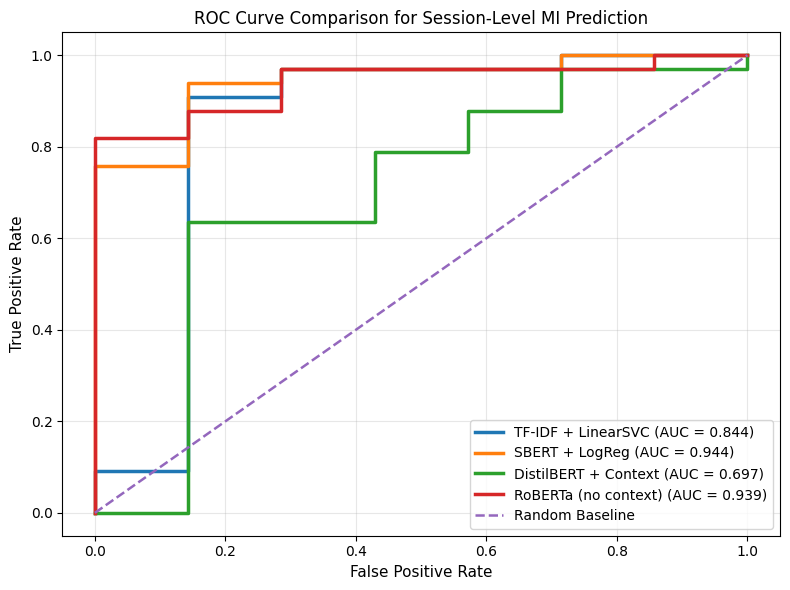

In [65]:
plt.figure(figsize=(8, 6))

# Model 1: TF-IDF + LinearSVC (baseline)
fpr_base, tpr_base, _ = roc_curve(
    session_test_features_baseline["mi_quality_binary"],
    session_test_prob_baseline
)
plt.plot(
    fpr_base, tpr_base,
    linewidth=2.5,
    label=f"TF-IDF + LinearSVC (AUC = {session_auc_baseline:.3f})"
)

# Model 2: SBERT + LogReg
fpr_sbert, tpr_sbert, _ = roc_curve(
    session_test_features_sbert["mi_quality_binary"],
    session_test_prob_sbert
)
plt.plot(
    fpr_sbert, tpr_sbert,
    linewidth=2.5,
    label=f"SBERT + LogReg (AUC = {session_auc_sbert:.3f})"
)

# Model 3: DistilBERT + Context
fpr_ctx, tpr_ctx, _ = roc_curve(
    session_test_features_ctx["mi_quality_binary"],
    session_test_prob_ctx
)
plt.plot(
    fpr_ctx, tpr_ctx,
    linewidth=2.5,
    label=f"DistilBERT + Context (AUC = {session_auc_ctx:.3f})"
)

# Model 4: RoBERTa (no context)
fpr_roberta, tpr_roberta, _ = roc_curve(
    session_test_features_roberta["mi_quality_binary"],
    session_test_prob_roberta
)
plt.plot(
    fpr_roberta, tpr_roberta,
    linewidth=2.5,
    label=f"RoBERTa (AUC = {session_auc_roberta:.3f})"
)

# Random baseline
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.8, label="Random Baseline")

plt.xlabel("False Positive Rate", fontsize=11)
plt.ylabel("True Positive Rate", fontsize=11)
plt.title("ROC Curve Comparison for Session-Level MI Prediction", fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The diagonal dashed line indicates a random baseline (AUC = 0.5), representing a model with no predictive capability. Models performing above this line exhibit useful discrimination between classes.

---
# V. Evaluation and Error Analysis
---

This section evaluates model performance in more detail using confusion matrices and per-class metrics.
We also inspect misclassified therapist utterances to better understand model limitations.

---
## 5.1. Therapist & Client Confusion Matrix
---

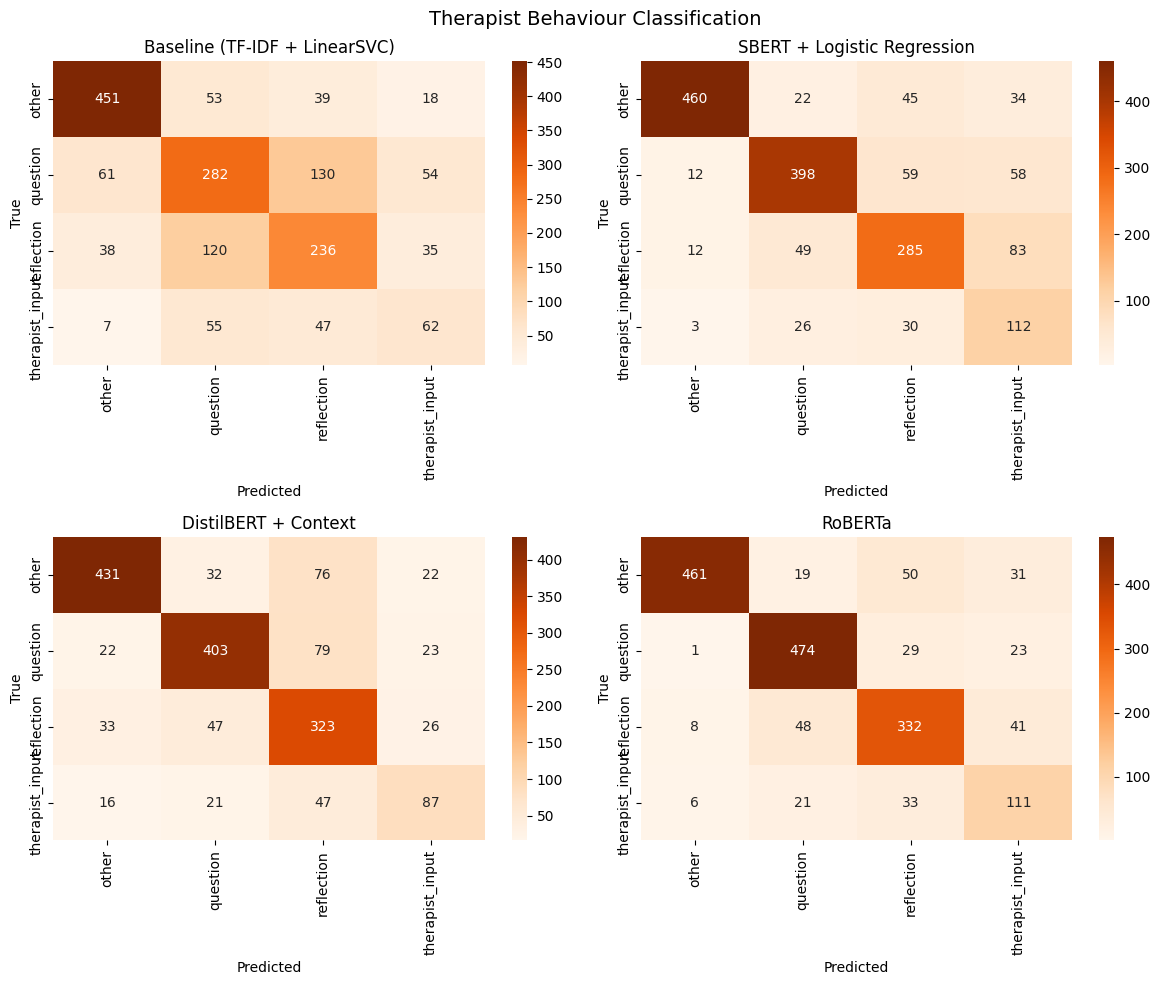

In [72]:
# ===============================
# THERAPIST CONFUSION MATRICES
# ===============================

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

therapist_labels = therapist_encoder.classes_

# Baseline
cm = confusion_matrix(therapist_test["therapist_y"], therapist_test_pred_baseline)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=therapist_labels,
            yticklabels=therapist_labels,
            ax=axes[0,0])
axes[0,0].set_title("Baseline (TF-IDF + LinearSVC)")

# SBERT
cm = confusion_matrix(therapist_test["therapist_y"], therapist_test_pred_sbert)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=therapist_labels,
            yticklabels=therapist_labels,
            ax=axes[0,1])
axes[0,1].set_title("SBERT + Logistic Regression")

# DistilBERT + Context
cm = confusion_matrix(therapist_test_ctx["therapist_y"], therapist_test_pred_ctx)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=therapist_labels,
            yticklabels=therapist_labels,
            ax=axes[1,0])
axes[1,0].set_title("DistilBERT + Context")

# RoBERTa
cm = confusion_matrix(therapist_test_roberta["therapist_y"], therapist_test_pred_roberta)
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=therapist_labels,
            yticklabels=therapist_labels,
            ax=axes[1,1])
axes[1,1].set_title("RoBERTa")

for ax in axes.flat:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Therapist Behaviour Classification", fontsize=14)
plt.tight_layout()
plt.show()

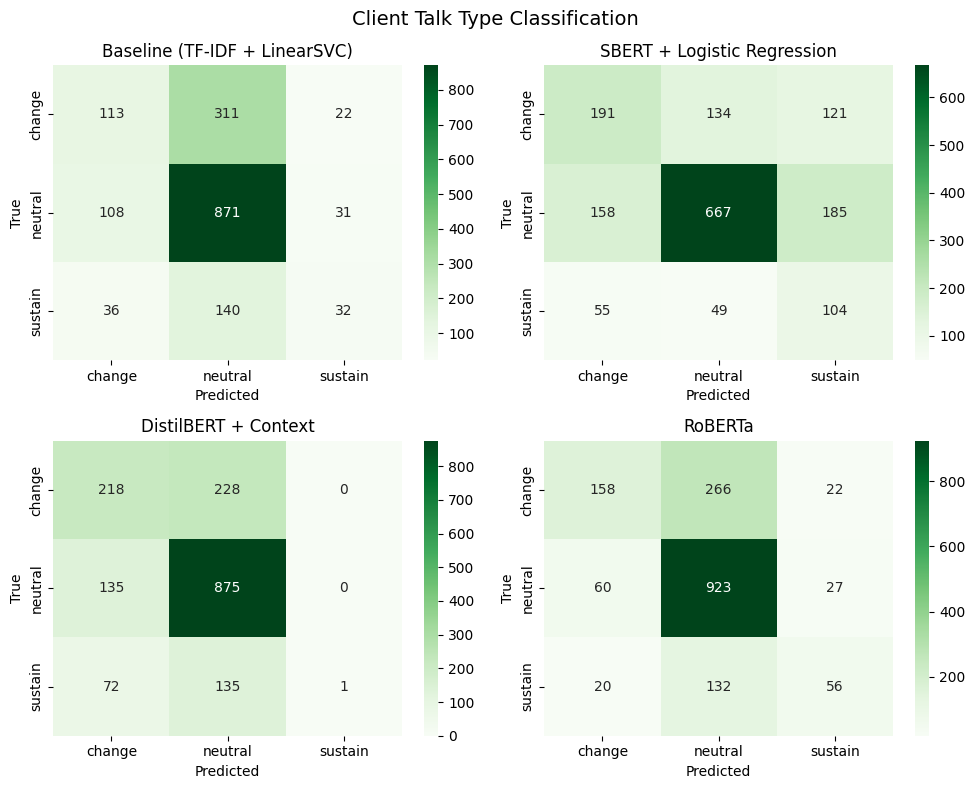

In [71]:
# ============================
# CLIENT CONFUSION MATRICES
# ============================

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

client_labels = client_encoder.classes_

# Baseline
cm = confusion_matrix(client_test["client_y"], client_test_pred_baseline)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=client_labels,
            yticklabels=client_labels,
            ax=axes[0,0])
axes[0,0].set_title("Baseline (TF-IDF + LinearSVC)")

# SBERT
cm = confusion_matrix(client_test["client_y"], client_test_pred_sbert)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=client_labels,
            yticklabels=client_labels,
            ax=axes[0,1])
axes[0,1].set_title("SBERT + Logistic Regression")

# DistilBERT + Context
cm = confusion_matrix(client_test_ctx["client_y"], client_test_pred_ctx)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=client_labels,
            yticklabels=client_labels,
            ax=axes[1,0])
axes[1,0].set_title("DistilBERT + Context")

# RoBERTa
cm = confusion_matrix(client_test_roberta["client_y"], client_test_pred_roberta)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=client_labels,
            yticklabels=client_labels,
            ax=axes[1,1])
axes[1,1].set_title("RoBERTa")

for ax in axes.flat:
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")

plt.suptitle("Client Talk Type Classification", fontsize=14)
plt.tight_layout()
plt.show()

**Therapist behaviour classification:**

Across the three models, clear differences are observed in classification performance.

- The SBERT + Logistic Regression model achieves the most consistent performance, with a strong diagonal across all classes, particularly for question and reflection. Misclassification between question and reflection is reduced compared to the baseline, indicating improved semantic understanding of therapist utterances.

- The baseline TF-IDF + LinearSVC model shows weaker separation between behaviour categories, with notable confusion between question and reflection, suggesting that surface-level lexical features are insufficient to distinguish nuanced therapeutic behaviours.

- The DistilBERT + Context model improves performance for reflection, showing a stronger diagonal compared to the baseline. However, it introduces increased confusion between other and reflection, indicating that while contextual information helps capture reflective responses, it may blur boundaries between similar discourse functions.

Hence, SBERT remains the most balanced model for therapist behaviour classification.

**Client talk type classification:**

The models exhibit different strengths for client utterances.

- The DistilBERT + Context model achieves the strongest performance for the dominant neutral class, with a highly concentrated diagonal, suggesting that contextual information helps identify conversational flow.

- However, this model performs poorly on the sustain class, with most instances misclassified as neutral, indicating a strong bias toward the majority class.

- The SBERT model provides a more balanced distribution, particularly improving recognition of sustain compared to the baseline, though still with notable confusion.

The baseline model shows the weakest performance overall, with heavy misclassification of change and sustain into neutral, reflecting limitations of bag-of-words representations.

---
## 5.2. Session Feature Coefficients
---

In [85]:
# Build coefficient tables
coef_baseline = pd.DataFrame({
    "feature": session_feature_cols,
    "coefficient": session_model_baseline.coef_[0]
}).set_index("feature")

coef_sbert = pd.DataFrame({
    "feature": session_feature_cols,
    "coefficient": session_model_sbert.coef_[0]
}).set_index("feature")

coef_ctx = pd.DataFrame({
    "feature": session_feature_cols,
    "coefficient": session_model_ctx.coef_[0]
}).set_index("feature")

coef_roberta = pd.DataFrame({
    "feature": session_feature_cols,
    "coefficient": session_model_roberta.coef_[0]
}).set_index("feature")

# Combine
coef_compare = pd.DataFrame({
    "TF-IDF + LinearSVC": coef_baseline["coefficient"],
    "SBERT + Logistic Regression": coef_sbert["coefficient"],
    "DistilBERT + Context": coef_ctx["coefficient"],
    "RoBERTa": coef_roberta["coefficient"]
})

# Final clean output only
coef_compare = coef_compare.loc[session_feature_cols].round(3)
coef_compare.index.name = None

def highlight_abs_max(row):
    max_idx = row.abs().idxmax()
    return [
        "background-color: #E8F6F3" if col == max_idx else ""
        for col in row.index
    ]

display(
    coef_compare.style
    .set_table_styles([
        {"selector": "th", "props": [("border", "1px solid black"), ("padding", "6px")]},
        {"selector": "td", "props": [("border", "1px solid black"), ("padding", "6px")]},
        {"selector": "table", "props": [("border-collapse", "collapse")]}
    ])
    .set_properties(**{"text-align": "center"})
    .apply(highlight_abs_max, axis=1) # Most important feature weight (largest magnitude)
)

,TF-IDF + LinearSVC,SBERT + Logistic Regression,DistilBERT + Context,RoBERTa
reflection_ratio,1.415000,1.611000,1.535000,1.885000
question_ratio,0.860000,0.602000,0.304000,0.393000
input_ratio,-3.342000,-2.821000,-2.862000,-3.092000
change_ratio,-0.553000,0.652000,-0.408000,0.968000
sustain_ratio,0.117000,-0.434000,0.012000,-0.549000


**Which model relies most on each behavioural signal?**

Features highlighted indicate the strongest influence (by absolute coefficient magnitude) for each behavioural signal across models.

- reflection_ratio → RoBERTa dominates
- input_ratio → TF-IDF penalizes hardest
- change_ratio → models disagree a lot
- sustain_ratio → weak / unstable across models

**Interpret behavioural signals across models**

This analysis helps explain how each model makes its decisions, not just how well it performs.

- reflection_ratio: strong positive → sessions with more therapist reflections → more likely high-quality MI  
  → all models agree on this → this is the most reliable signal

- input_ratio: strong negative → therapists who talk too much or give too much advice → worse MI  
  → consistently negative across all models → strongest negative driver

- change_ratio: depends on model  
  → SBERT: positive (uses client change talk well)  
  → RoBERTa: positive but less stable  
  → DistilBERT + Context: negative (unexpected)  
  → shows that some models understand client behaviour better than others

- sustain_ratio: weak / inconsistent → small or negative values  
  → models do not rely on this feature much → less useful for prediction

**Model behaviour differences**

- SBERT + Logistic Regression  
  → uses both therapist and client signals  
  → reflection_ratio (+1.611) and change_ratio (+0.652) both meaningful  
  → most balanced and interpretable model

- DistilBERT + Context  
  → weaker and inconsistent signals  
  → change_ratio becomes negative (−0.408)  
  → suggests context may blur important behavioural patterns

- RoBERTa  
  → strongest focus on therapist behaviour  
  → reflection_ratio highest (+1.885)  
  → still uses change_ratio (+0.968) but less balanced  
  → relies more on dominant signals

- TF-IDF + LinearSVC (baseline)  
  → follows expected direction but exaggerated  
  → input_ratio very negative (−3.342)  
  → relies too much on one feature → less robust

**Relatability & Importance**

- MI quality depends on both therapist and client behaviour  
- models like SBERT capture both → more reliable and meaningful  
- models that ignore or distort client signals → miss important interaction dynamics  

→ therefore, analysing feature contributions helps us understand not just which model is better, but whether the model truly reflects how Motivational Interviewing works in practice



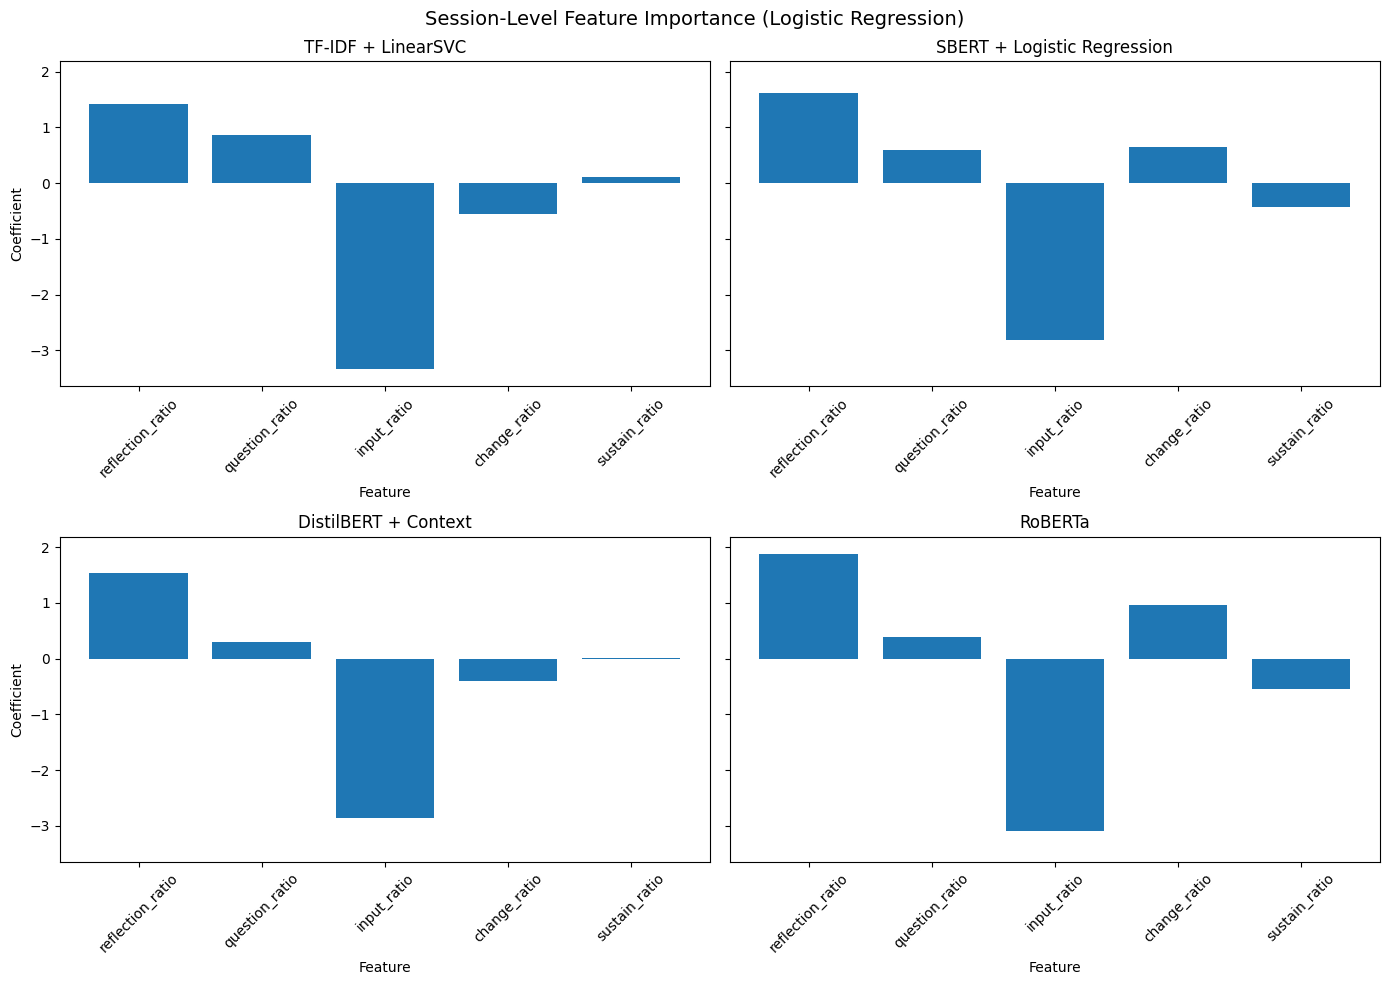

In [83]:
# Session-Level Feature Importance (2x2)

coef_baseline = coef_baseline.loc[session_feature_cols]
coef_sbert    = coef_sbert.loc[session_feature_cols]
coef_ctx      = coef_ctx.loc[session_feature_cols]
coef_roberta  = coef_roberta.loc[session_feature_cols]

# Shared y-axis range
all_vals = pd.concat([
    coef_baseline["coefficient"],
    coef_sbert["coefficient"],
    coef_ctx["coefficient"],
    coef_roberta["coefficient"]
])
ymin = all_vals.min() - 0.3
ymax = all_vals.max() + 0.3

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=True)

# Baseline
axes[0,0].bar(coef_baseline.index, coef_baseline["coefficient"])
axes[0,0].set_title("TF-IDF + LinearSVC")
axes[0,0].set_xlabel("Feature")
axes[0,0].set_ylabel("Coefficient")
axes[0,0].tick_params(axis="x", rotation=45)
axes[0,0].set_ylim(ymin, ymax)

# SBERT
axes[0,1].bar(coef_sbert.index, coef_sbert["coefficient"])
axes[0,1].set_title("SBERT + Logistic Regression")
axes[0,1].set_xlabel("Feature")
axes[0,1].tick_params(axis="x", rotation=45)
axes[0,1].set_ylim(ymin, ymax)

# DistilBERT + Context
axes[1,0].bar(coef_ctx.index, coef_ctx["coefficient"])
axes[1,0].set_title("DistilBERT + Context")
axes[1,0].set_xlabel("Feature")
axes[1,0].set_ylabel("Coefficient")
axes[1,0].tick_params(axis="x", rotation=45)
axes[1,0].set_ylim(ymin, ymax)

# RoBERTa
axes[1,1].bar(coef_roberta.index, coef_roberta["coefficient"])
axes[1,1].set_title("RoBERTa")
axes[1,1].set_xlabel("Feature")
axes[1,1].tick_params(axis="x", rotation=45)
axes[1,1].set_ylim(ymin, ymax)

plt.suptitle("Session-Level Feature Importance (Logistic Regression)", fontsize=14)
plt.tight_layout()
plt.show()

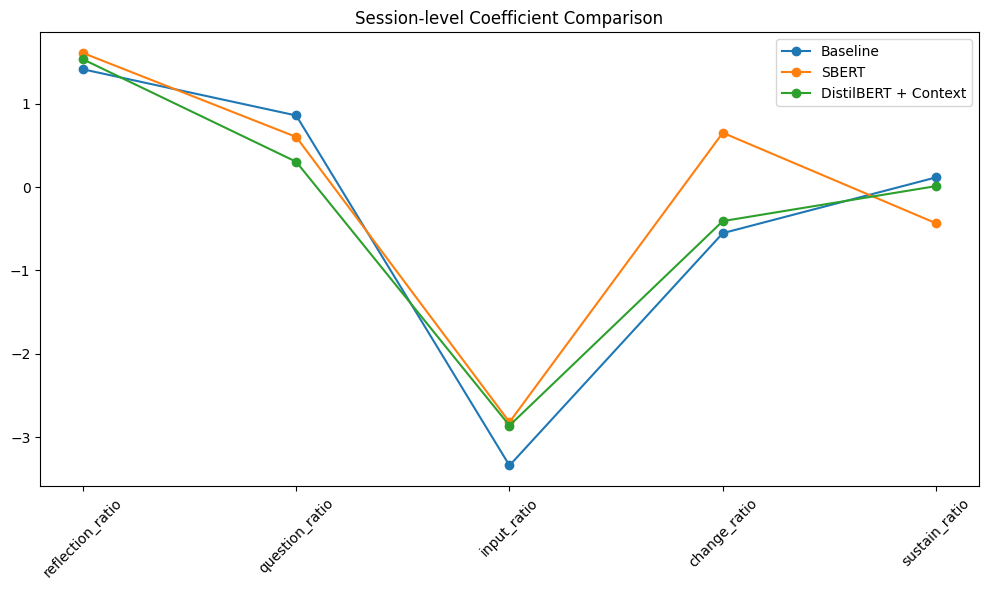

In [53]:
def get_coef_df (model, name):
  return pd. DataFrame({
      "feature": session_feature_cols,
      "coef": model.coef_[0],
      "model": name
  })

coef_baseline = get_coef_df(session_model_baseline, "Baseline")
coef_sbert = get_coef_df (session_model_sbert, "SBERT")
coef_ctx = get_coef_df(session_model_ctx, "DistilBERT + Context")

coef_all = pd.concat([coef_baseline, coef_sbert, coef_ctx])

top_features = coef_all.groupby("feature")["coef"].mean().abs().sort_values(ascending=False).head(10).index

plot_df = coef_all[coef_all["feature"].isin(top_features)]

plt.figure(figsize=(10,6))

for model in plot_df["model"].unique():
    subset = plot_df[plot_df["model"] == model]
    plt.plot(subset["feature"], subset["coef"], marker='o', label=model)

plt.xticks(rotation=45)
plt.title("Session-level Coefficient Comparison")
plt.legend()
plt.tight_layout()
plt.show()

The session-level logistic regression coefficients reveal highly consistent behavioural patterns across all models. In particular, reflection_ratio emerges as the strongest positive predictor of high MI quality, while therapist input_ratio consistently shows the largest negative effect. These findings align closely with Motivational Interviewing principles, where reflective listening is a key indicator of effective practice, and excessive directive input undermines MI fidelity.

In contrast, client-related features are less stable across models. While change_ratio generally contributes positively and sustain_ratio tends to have a weak or negative effect, these signals are more variable, suggesting that therapist behaviours are more reliable indicators of session-level MI quality than client language alone.

**Model comparison:**

- The SBERT + Logistic Regression pipeline demonstrates a balanced and interpretable coefficient structure. It captures both therapist and client signals effectively, assigning a strong positive weight to reflection_ratio and a meaningful contribution to change_ratio, while maintaining a clear negative association with therapist input. This indicates that SBERT produces semantically meaningful utterance representations that translate into stable and informative session-level features.

- The TF-IDF + LinearSVC baseline reflects similar directional trends but exhibits more extreme coefficients, particularly for therapist input. This suggests a heavier reliance on a small number of dominant features, indicating lower robustness and greater sensitivity to feature distributions.

- The DistilBERT + Context model shows weaker and less consistent coefficients overall. Although reflection and question ratios remain positive, their magnitudes are reduced, and the contribution of change_ratio becomes unstable. This suggests that incorporating conversational context does not enhance, and may even dilute, the discriminative power of aggregated behavioural features at the session level.

- RoBERTa produces the strongest overall coefficient magnitudes, particularly for reflection_ratio, indicating high sensitivity to key behavioural signals. However, its reliance remains primarily on therapist-driven features, with client-related signals showing less consistent contributions. This suggests that while RoBERTa improves predictive strength, it does not fundamentally change the feature dynamics observed in other models.

**Key finding:** Improvements at the utterance level do not necessarily translate into better session-level performance. While contextual and deep transformer models enhance local classification, they may introduce bias or reduce variability in aggregated features, limiting their effectiveness for downstream session-level prediction.

In essence, the SBERT pipeline achieves the best balance between semantic representation and feature stability, leading to the most reliable session-level MI quality prediction. These results highlight that stable behavioural feature distributions, rather than model complexity alone, are critical for effective intervention fidelity assessment.

---
# VI. Conclusion
---

At this point the pipeline does two things:

1. **Utterance-level behaviour classification** using the main therapist behaviour label.  
2. **Session-level fidelity analysis** using fine-grained subtype annotations from AnnoMI-full.

This is a stronger thesis framing than classification alone because it connects model outputs to clinically meaningful fidelity indicators such as:
- open question ratio
- complex reflection ratio
- reflection-to-question ratio
- advice ratio
